# Sampling Parameter Sweep — Accuracy Analysis

Investigates how vLLM sampling parameters affect LLM vulnerability detection accuracy.
Covers **20 parameter configurations** of Qwen3-4B across **4 datasets**:
CASTLE, CVEFixes (C), CVEFixes (Python), JitVul.

Swept parameters: `temperature`, `min_p`, `top_k`, `top_p`, `presence_penalty`, `repeat_penalty`

Experiments are split into two modes:
- **Thinking** (`is_thinking_enabled=True`) — chain-of-thought enabled; **primary analysis**
- **Non-Thinking** (`is_thinking_enabled=False`) — direct response mode; used for comparison

Key questions:
- Which parameter type has the greatest impact on accuracy and FNR?
- Which specific values improve or degrade detection performance?
- Are parameter effects consistent across datasets?
- Does thinking mode outperform non-thinking, and does it interact with parameter choice?

In [5]:
import json
import math
import re
from pathlib import Path

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [6]:
## Configuration

PROJECT_ROOT = Path('__file__').resolve().parent.parent
RESULTS_ROOT = PROJECT_ROOT / 'results'

# model_name suffix (after stripping 'qwen3-4b-' and optional 'nt-') -> (param_type, param_value)
PARAM_MAP = {
    'base':         ('baseline',         float('nan')),
    'temp-00':      ('temperature',      0.00),
    'temp-03':      ('temperature',      0.30),
    'temp-09':      ('temperature',      0.90),
    'min-p-002':    ('min_p',            0.02),
    'min-p-005':    ('min_p',            0.05),
    'min-p-010':    ('min_p',            0.10),
    'top-k-020':    ('top_k',           20.00),
    'top-k-040':    ('top_k',           40.00),
    'top-k-080':    ('top_k',           80.00),
    'top-p-080':    ('top_p',            0.80),
    'top-p-090':    ('top_p',            0.90),
    'top-p-095':    ('top_p',            0.95),
    'presence-025': ('presence_penalty', 0.25),
    'presence-050': ('presence_penalty', 0.50),
    'presence-100': ('presence_penalty', 1.00),
    'repeat-105':   ('repeat_penalty',   1.05),
    'repeat-110':   ('repeat_penalty',   1.10),
    'repeat-120':   ('repeat_penalty',   1.20),
    'repeat-130':   ('repeat_penalty',   1.30),
}

PARAM_TYPE_DISPLAY = {
    'temperature':      'Temperature',
    'min_p':            'Min-P',
    'top_k':            'Top-K',
    'top_p':            'Top-P',
    'presence_penalty': 'Presence Penalty',
    'repeat_penalty':   'Repeat Penalty',
    'baseline':         'Baseline',
}

DATASET_DISPLAY = {
    'castle':          'CASTLE',
    'cvefixes_c':      'CVEFixes (C)',
    'cvefixes_python': 'CVEFixes (Python)',
    'jitvul':          'JitVul',
}

DATASETS_ORDERED    = ['castle', 'cvefixes_c', 'cvefixes_python', 'jitvul']
PARAM_TYPES_ORDERED = ['temperature', 'min_p', 'top_k', 'top_p', 'presence_penalty', 'repeat_penalty']

DATASET_COLORS = {
    'castle':          '#4e79a7',
    'cvefixes_c':      '#f28e2b',
    'cvefixes_python': '#e15759',
    'jitvul':          '#59a14f',
}

PARAM_TYPE_COLORS = {
    'temperature':      '#4e79a7',
    'min_p':            '#f28e2b',
    'top_k':            '#e15759',
    'top_p':            '#59a14f',
    'presence_penalty': '#b07aa1',
    'repeat_penalty':   '#ff9da7',
    'baseline':         '#9c755f',
}

THINKING_COLOR    = '#4e79a7'   # blue  — thinking mode
NT_COLOR          = '#f28e2b'   # orange — non-thinking mode

In [7]:
## Data loading + derived metrics
## Reads individual metrics_summary_*.json files from results/
## Experiments are split into thinking (primary) and non-thinking (comparison).
## Multiple files for the same config are aggregated by summing confusion matrices.

def _dataset_key(path: str) -> str:
    if 'castle' in path:
        return 'castle'
    if 'jitvul' in path:
        return 'jitvul'
    if 'cvefixes' in path:
        return 'cvefixes_python' if 'python' in path else 'cvefixes_c'
    raise ValueError(f'Unknown dataset path: {path}')


def _parse_param(model_name: str) -> tuple:
    """Map a model name to (param_type, param_value). Strips qwen3-4b- and nt- prefixes."""
    remainder = re.sub(r'^qwen3-4b-(?:nt-)?', '', model_name)
    return PARAM_MAP.get(remainder, ('unknown', float('nan')))


def _recompute_metrics(tp: int, tn: int, fp: int, fn: int) -> dict:
    """Compute all classification metrics from raw confusion matrix counts."""
    n    = tp + tn + fp + fn
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc   = (tp * tn - fp * fn) / denom if denom else 0.0
    return dict(
        accuracy=(tp + tn) / n if n else 0.0,
        precision=prec, recall=rec, f1=f1, specificity=spec, MCC=mcc,
    )


def _load_metrics_file(path: Path) -> dict | None:
    """Load a metrics_summary JSON; supports both flat (old) and nested-model (new) formats."""
    try:
        with open(path) as f:
            d = json.load(f)
    except Exception:
        return None
    bi = d['benchmark_info']
    cm = d['metrics']['details']['confusion_matrix']
    if 'model' in bi:                          # new nested format
        model_name    = bi['model']['model_name']
        thinking      = bool(bi['model'].get('is_thinking_enabled', True))
        stats         = bi.get('stats', {})
        ts            = stats.get('tokens_used_stats', {})
        ps            = stats.get('processing_time_stats', {})
        tokens_avg_bi = stats.get('tokens_used_avg', float('nan'))
        time_avg_bi   = stats.get('avg_time_per_sample', float('nan'))
        total_samples = stats.get('total_samples', 0)
    else:                                      # old flat format
        model_name    = bi.get('model_name', '')
        thinking      = bool(bi.get('is_thinking_enabled', True))
        ts            = bi.get('tokens_used_stats', {})
        ps            = bi.get('processing_time_stats', {})
        tokens_avg_bi = bi.get('tokens_used_avg', float('nan'))
        time_avg_bi   = bi.get('avg_time_per_sample', float('nan'))
        total_samples = bi.get('total_samples', 0)
    param_suffix            = re.sub(r'^qwen3-4b-(?:nt-)?', '', model_name)
    param_type, param_value = PARAM_MAP.get(param_suffix, ('unknown', float('nan')))
    return {
        'model_name':    model_name,
        'param_suffix':  param_suffix,
        'experiment':    bi.get('experiment_name', ''),
        'dataset':       _dataset_key(bi.get('dataset_path', '')),
        'thinking':      thinking,
        'param_type':    param_type,
        'param_value':   param_value,
        'TP':            cm['true_positives'],
        'TN':            cm['true_negatives'],
        'FP':            cm['false_positives'],
        'FN':            cm['false_negatives'],
        'tokens_avg':    ts.get('mean', tokens_avg_bi),
        'tokens_std':    ts.get('std', float('nan')),
        'time_avg':      ps.get('mean', time_avg_bi),
        'total_samples': total_samples,
    }


# Load all metrics_summary_*.json from sampling_sweep experiments
all_files = sorted(
    RESULTS_ROOT.glob('*/sampling_sweep_binary*/*/*/step_by_step/metrics_summary_*.json')
)
raw_rows = [r for f in all_files if (r := _load_metrics_file(f)) is not None]
raw_df = pd.DataFrame(raw_rows)

# Deduplication for thinking=True:
# Prefer 'sampling_sweep_binary_thinking' (canonical) over old 'sampling_sweep_binary'
# thinking runs covering the same (param_suffix, dataset).  Old runs are kept only as a
# fallback for datasets that have no _thinking experiment (e.g. JitVul).
has_thinking_exp = set(
    raw_df[raw_df['experiment'] == 'sampling_sweep_binary_thinking']
    [['param_suffix', 'dataset']].itertuples(index=False, name=None)
)
mask_keep = (
    ~raw_df['thinking']                                           # always keep non-thinking
    | (raw_df['experiment'] == 'sampling_sweep_binary_thinking')  # canonical thinking
    | ~raw_df.apply(                                              # fallback (JitVul, etc.)
        lambda r: (r['param_suffix'], r['dataset']) in has_thinking_exp, axis=1
    )
)
raw_df = raw_df[mask_keep].copy()

# Aggregate by summing CMs across multiple files for the same config.
# Note: groupby keys (param_suffix, dataset, thinking) are excluded from g when
# include_groups=False, so they are not referenced inside the function — they are
# restored automatically via reset_index().
def _agg_group(g):
    tp, tn = int(g['TP'].sum()), int(g['TN'].sum())
    fp, fn = int(g['FP'].sum()), int(g['FN'].sum())
    return pd.Series({
        'model_name':    g['model_name'].iloc[0],
        'param_type':    g['param_type'].iloc[0],
        'param_value':   g['param_value'].iloc[0],
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'tokens_avg':    g['tokens_avg'].mean(),
        'tokens_std':    g['tokens_std'].mean(),
        'time_avg':      g['time_avg'].mean(),
        'total_samples': int(g['total_samples'].sum()),
        'n_runs':        len(g),
        **_recompute_metrics(tp, tn, fp, fn),
    })

df_all = (
    raw_df
    .groupby(['param_suffix', 'dataset', 'thinking'], sort=False)
    .apply(_agg_group, include_groups=False)
    .reset_index()   # restores param_suffix, dataset, thinking as columns
)

# Derived metrics
df_all['FNR']               = 1 - df_all['recall']
df_all['FPR']               = 1 - df_all['specificity']
df_all['balanced_accuracy'] = (df_all['recall'] + df_all['specificity']) / 2
df_all['youden_j']          = df_all['recall'] + df_all['specificity'] - 1
df_all['dataset_label']     = df_all['dataset'].map(DATASET_DISPLAY)
df_all['param_label']       = df_all['param_suffix']

# Attach per-dataset baselines, computed separately per thinking mode
def _attach_baselines(sub):
    bl = (
        sub[sub['param_type'] == 'baseline']
        [['dataset', 'accuracy', 'FNR', 'balanced_accuracy', 'MCC']]
        .rename(columns={'accuracy': 'bl_acc', 'FNR': 'bl_fnr',
                         'balanced_accuracy': 'bl_bacc', 'MCC': 'bl_mcc'})
    )
    return sub.merge(bl, on='dataset', how='left')

df_all = pd.concat([
    _attach_baselines(df_all[df_all['thinking']].copy()),
    _attach_baselines(df_all[~df_all['thinking']].copy()),
]).reset_index(drop=True)
df_all['delta_acc']  = df_all['accuracy']          - df_all['bl_acc']
df_all['delta_fnr']  = df_all['FNR']               - df_all['bl_fnr']
df_all['delta_bacc'] = df_all['balanced_accuracy'] - df_all['bl_bacc']
df_all['delta_mcc']  = df_all['MCC']               - df_all['bl_mcc']

# df  = thinking-only  (primary — all existing analysis cells use this)
# df_nt = non-thinking (used in the comparison section)
df    = df_all[df_all['thinking']].copy().reset_index(drop=True)
df_nt = df_all[~df_all['thinking']].copy().reset_index(drop=True)

# Report
multi = df_all[df_all['n_runs'] > 1][['param_suffix', 'dataset', 'thinking', 'n_runs']]
print(f'Raw experiment files loaded : {len(raw_rows)}')
print(f'Unique configs (aggregated) : {len(df_all)}')
print(f'  Thinking (primary)        : {len(df)}')
print(f'  Non-thinking              : {len(df_nt)}')
if not multi.empty:
    print(f'\nConfigs with >1 run (CMs summed):')
    print(multi.sort_values('n_runs', ascending=False).to_string(index=False))

print(f'\nThinking datasets     : {sorted(df["dataset"].unique())}')
print(f'Non-thinking datasets : {sorted(df_nt["dataset"].unique())}')
print(f'Param types (thinking): {sorted(df["param_type"].unique())}')
df_all.groupby(['dataset', 'param_type', 'thinking']).size().unstack(['thinking', 'param_type'], fill_value=0)

Raw experiment files loaded : 196
Unique configs (aggregated) : 139
  Thinking (primary)        : 79
  Non-thinking              : 60

Thinking datasets     : ['castle', 'cvefixes_c', 'cvefixes_python', 'jitvul']
Non-thinking datasets : ['castle', 'cvefixes_c', 'cvefixes_python']
Param types (thinking): ['baseline', 'min_p', 'presence_penalty', 'repeat_penalty', 'temperature', 'top_k', 'top_p']


thinking,False,True,False,True,False,True,False,True,False,True,False,True,False,True
param_type,baseline,baseline,min_p,min_p,presence_penalty,presence_penalty,repeat_penalty,repeat_penalty,temperature,temperature,top_k,top_k,top_p,top_p
dataset,,,,,,,,,,,,,,
castle,1,1,3,3,3,3,4,4,3,3,3,3,3,3
cvefixes_c,1,1,3,3,3,3,4,4,3,3,3,3,3,3
cvefixes_python,1,1,3,3,3,3,4,4,3,3,3,3,3,3
jitvul,0,1,0,3,0,3,0,3,0,3,0,3,0,3


## Overview

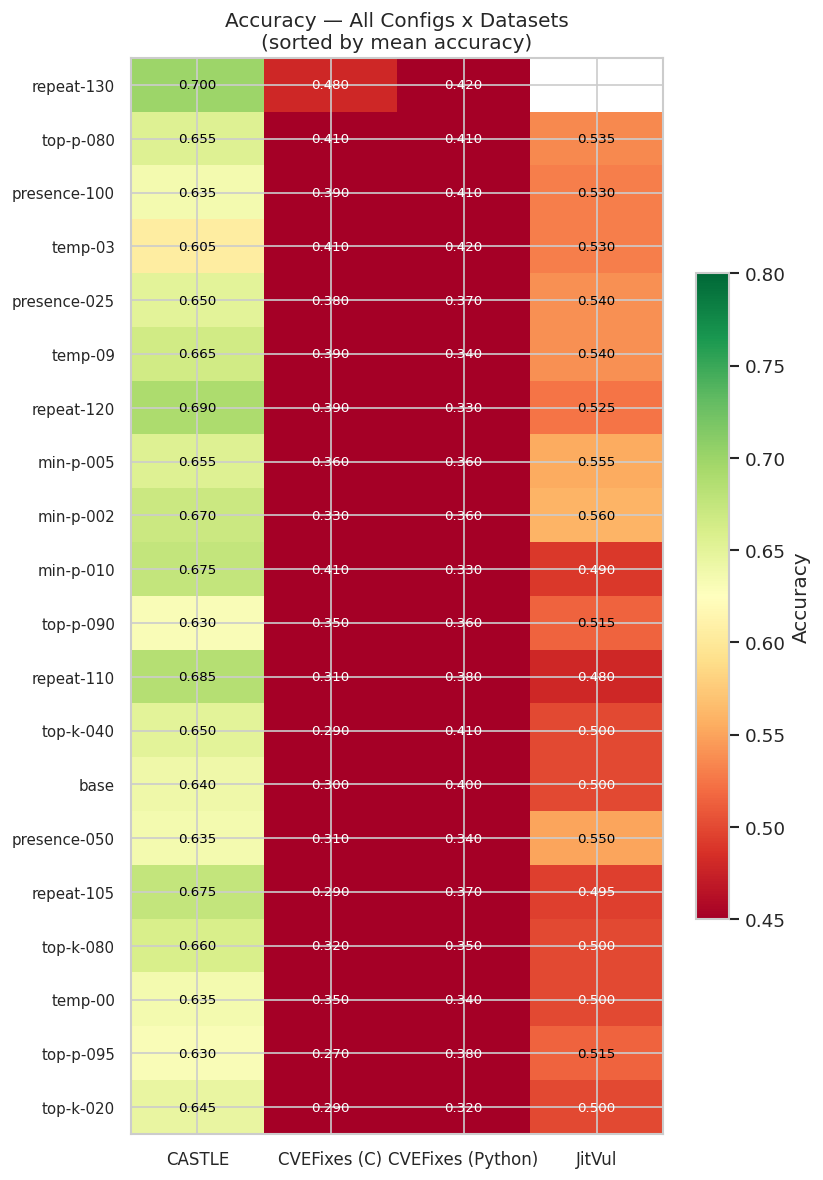

In [8]:
## Accuracy heatmap — all configs x all datasets (sorted by mean accuracy)

pivot = (
    df[df['param_type'] != 'unknown']
    .pivot_table(index='param_label', columns='dataset', values='accuracy', aggfunc='first')
    .reindex(columns=DATASETS_ORDERED)
)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
pivot.columns = [DATASET_DISPLAY[c] for c in pivot.columns]
pivot.index.name = 'Config'

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(pivot.values.astype(float), cmap='RdYlGn', vmin=0.45, vmax=0.80, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title('Accuracy — All Configs x Datasets\n(sorted by mean accuracy)', fontsize=12)
for i in range(len(pivot)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                    color='black' if 0.5 < v < 0.72 else 'white')
plt.colorbar(im, ax=ax, shrink=0.6, label='Accuracy')
fig.tight_layout()
plt.show()

## Parameter Type Impact

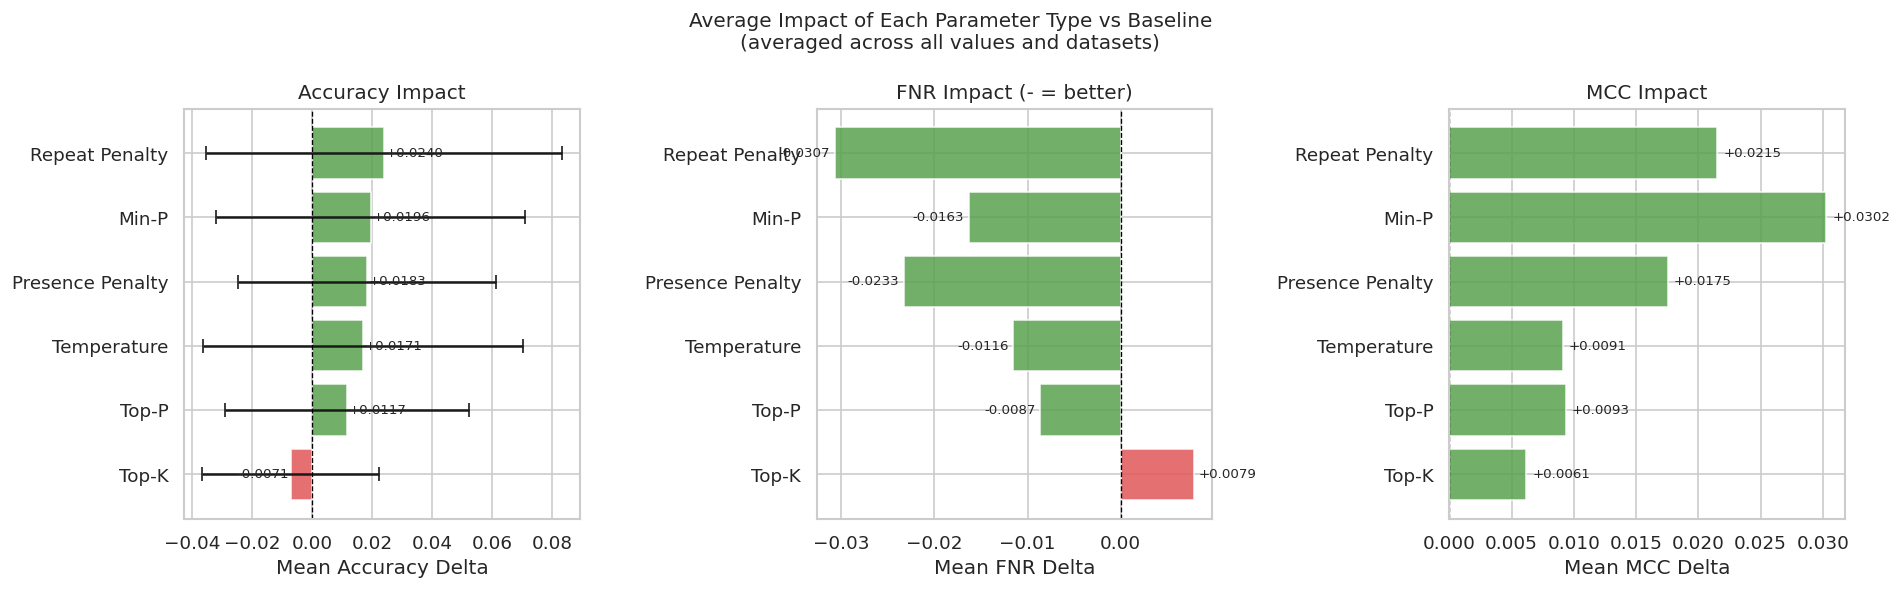

,Param Type,mean_acc,mean_delta_acc,std_delta_acc,max_delta_acc,min_delta_acc,mean_delta_fnr,mean_delta_mcc
0,Top-K,0.4529,-0.0071,+0.0294,+0.0200,-0.0800,+0.0079,+0.0061
1,Top-P,0.4717,+0.0117,+0.0405,+0.1100,-0.0400,-0.0087,+0.0093
2,Temperature,0.4771,+0.0171,+0.0532,+0.1100,-0.0600,-0.0116,+0.0091
3,Presence Penalty,0.4783,+0.0183,+0.0430,+0.0900,-0.0600,-0.0233,+0.0175
4,Min-P,0.4796,+0.0196,+0.0515,+0.1100,-0.0700,-0.0163,+0.0302
5,Repeat Penalty,0.4813,+0.0240,+0.0592,+0.1800,-0.0700,-0.0307,+0.0215


In [9]:
## Which parameter type moves the needle most? (avg delta vs baseline across all values and datasets)

sweep_df = df[df['param_type'].isin(PARAM_TYPES_ORDERED)].copy()

pt_summary = (
    sweep_df
    .groupby('param_type')
    .agg(
        mean_acc      =('accuracy',   'mean'),
        mean_delta_acc=('delta_acc',  'mean'),
        std_delta_acc =('delta_acc',  'std'),
        max_delta_acc =('delta_acc',  'max'),
        min_delta_acc =('delta_acc',  'min'),
        mean_delta_fnr=('delta_fnr',  'mean'),
        mean_delta_mcc=('delta_mcc',  'mean'),
    )
    .reset_index()
)
pt_summary['label'] = pt_summary['param_type'].map(PARAM_TYPE_DISPLAY)
pt_summary = pt_summary.sort_values('mean_delta_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, xlabel, title, flip_green) in zip(axes, [
    ('mean_delta_acc', 'Mean Accuracy Delta',        'Accuracy Impact',         False),
    ('mean_delta_fnr', 'Mean FNR Delta',             'FNR Impact (- = better)', True),
    ('mean_delta_mcc', 'Mean MCC Delta',             'MCC Impact',              False),
]):
    vals   = pt_summary[col].values
    colors = []
    for v in vals:
        if flip_green:
            colors.append('#59a14f' if v <= 0 else '#e15759')
        else:
            colors.append('#59a14f' if v >= 0 else '#e15759')
    ax.barh(pt_summary['label'], vals, color=colors, alpha=0.85,
            xerr=pt_summary.get('std_delta_acc') if col == 'mean_delta_acc' else None,
            capsize=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    for i, v in enumerate(vals):
        ax.text(v + (5e-4 if v >= 0 else -5e-4), i,
                f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

fig.suptitle('Average Impact of Each Parameter Type vs Baseline\n(averaged across all values and datasets)',
             fontsize=12)
fig.tight_layout()
plt.show()

display(
    pt_summary[['label', 'mean_acc', 'mean_delta_acc', 'std_delta_acc',
                'max_delta_acc', 'min_delta_acc', 'mean_delta_fnr', 'mean_delta_mcc']]
    .rename(columns={'label': 'Param Type'})
    .round(4)
    .style
    .background_gradient(subset=['mean_delta_acc', 'mean_delta_mcc'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['mean_delta_fnr'], cmap='RdYlGn_r', axis=0)
    .format('{:+.4f}', subset=['mean_delta_acc', 'std_delta_acc', 'max_delta_acc',
                               'min_delta_acc', 'mean_delta_fnr', 'mean_delta_mcc'])
    .format('{:.4f}', subset=['mean_acc'])
)

## Accuracy vs Parameter Value

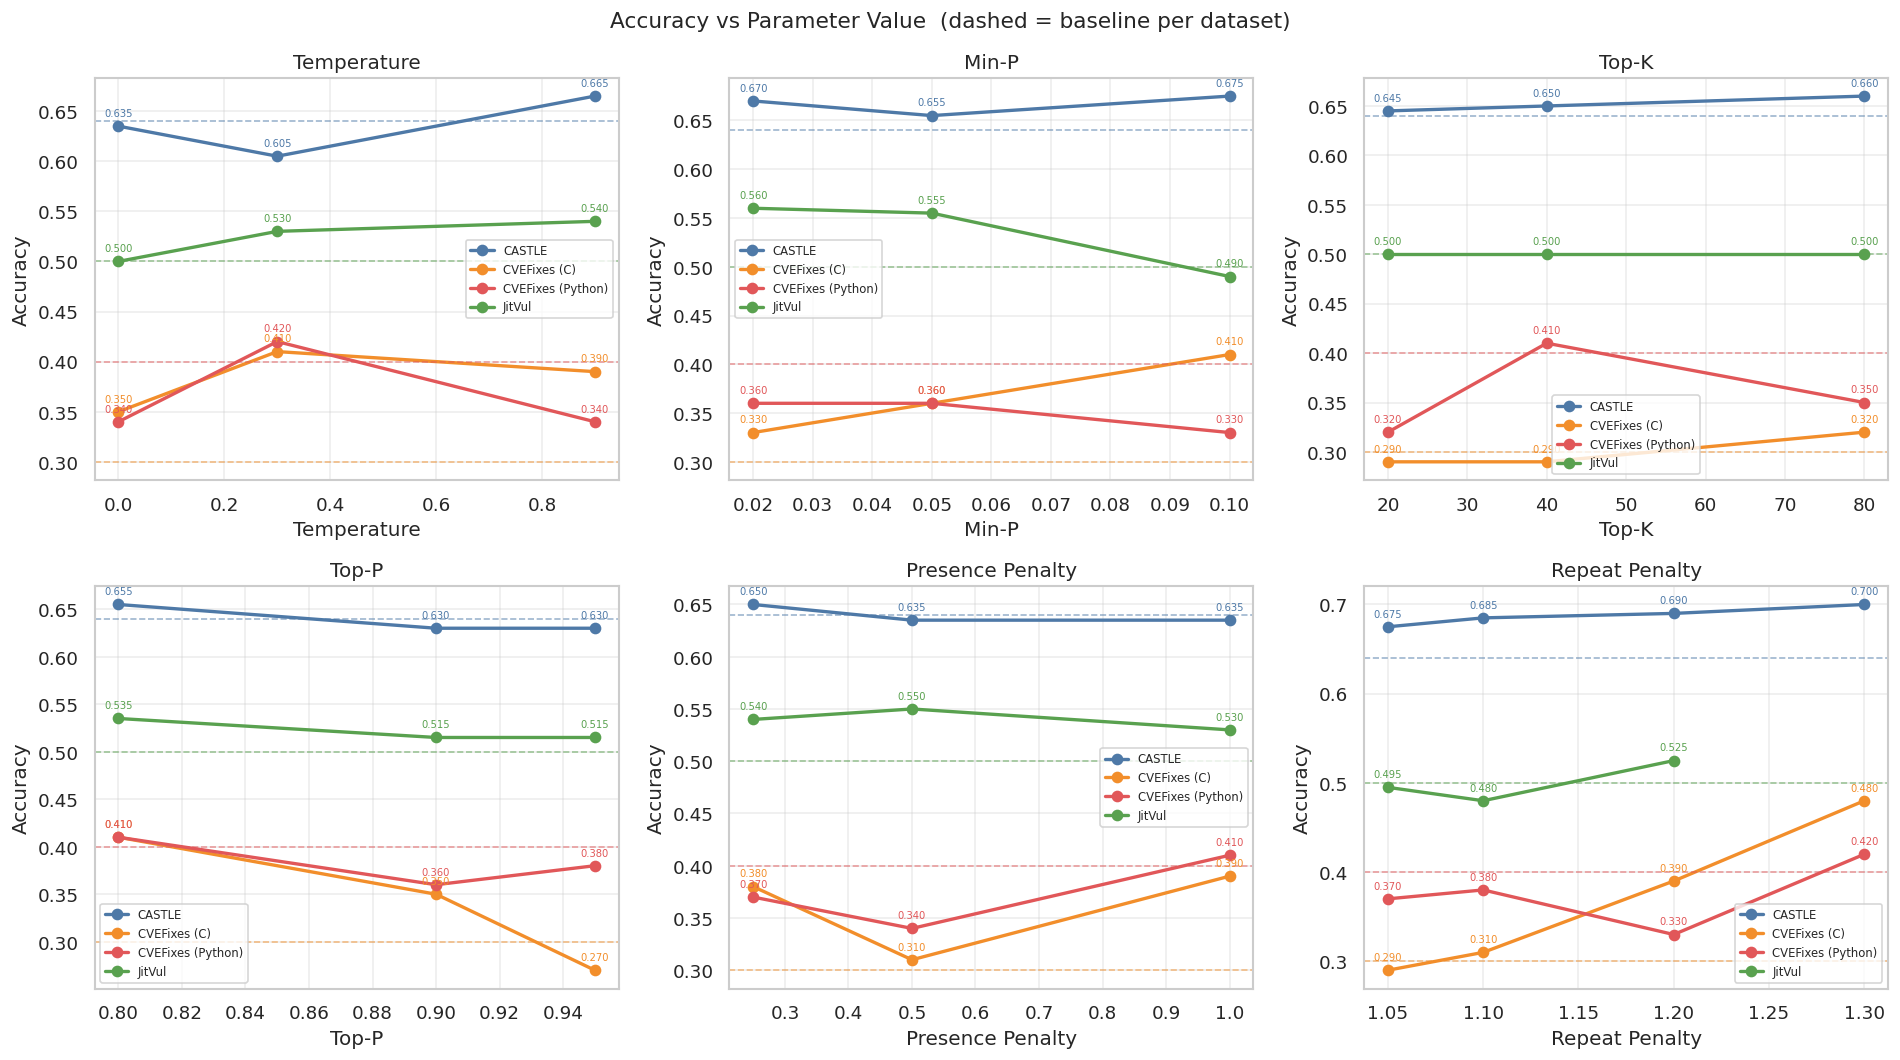

In [10]:
## Accuracy vs parameter value — 2x3 grid, one panel per parameter type
## Dashed horizontal lines = baseline accuracy per dataset

baseline_by_ds = df[df['param_type'] == 'baseline'].set_index('dataset')[['accuracy', 'FNR']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['accuracy'],
                marker='o', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        # Annotate each point with its config label
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['accuracy']:.3f}",
                        (row['param_value'], row['accuracy']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=6, color=DATASET_COLORS[ds])
        # Baseline reference line
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'accuracy'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('Accuracy')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('Accuracy vs Parameter Value  (dashed = baseline per dataset)', fontsize=13)
fig.tight_layout()
plt.show()

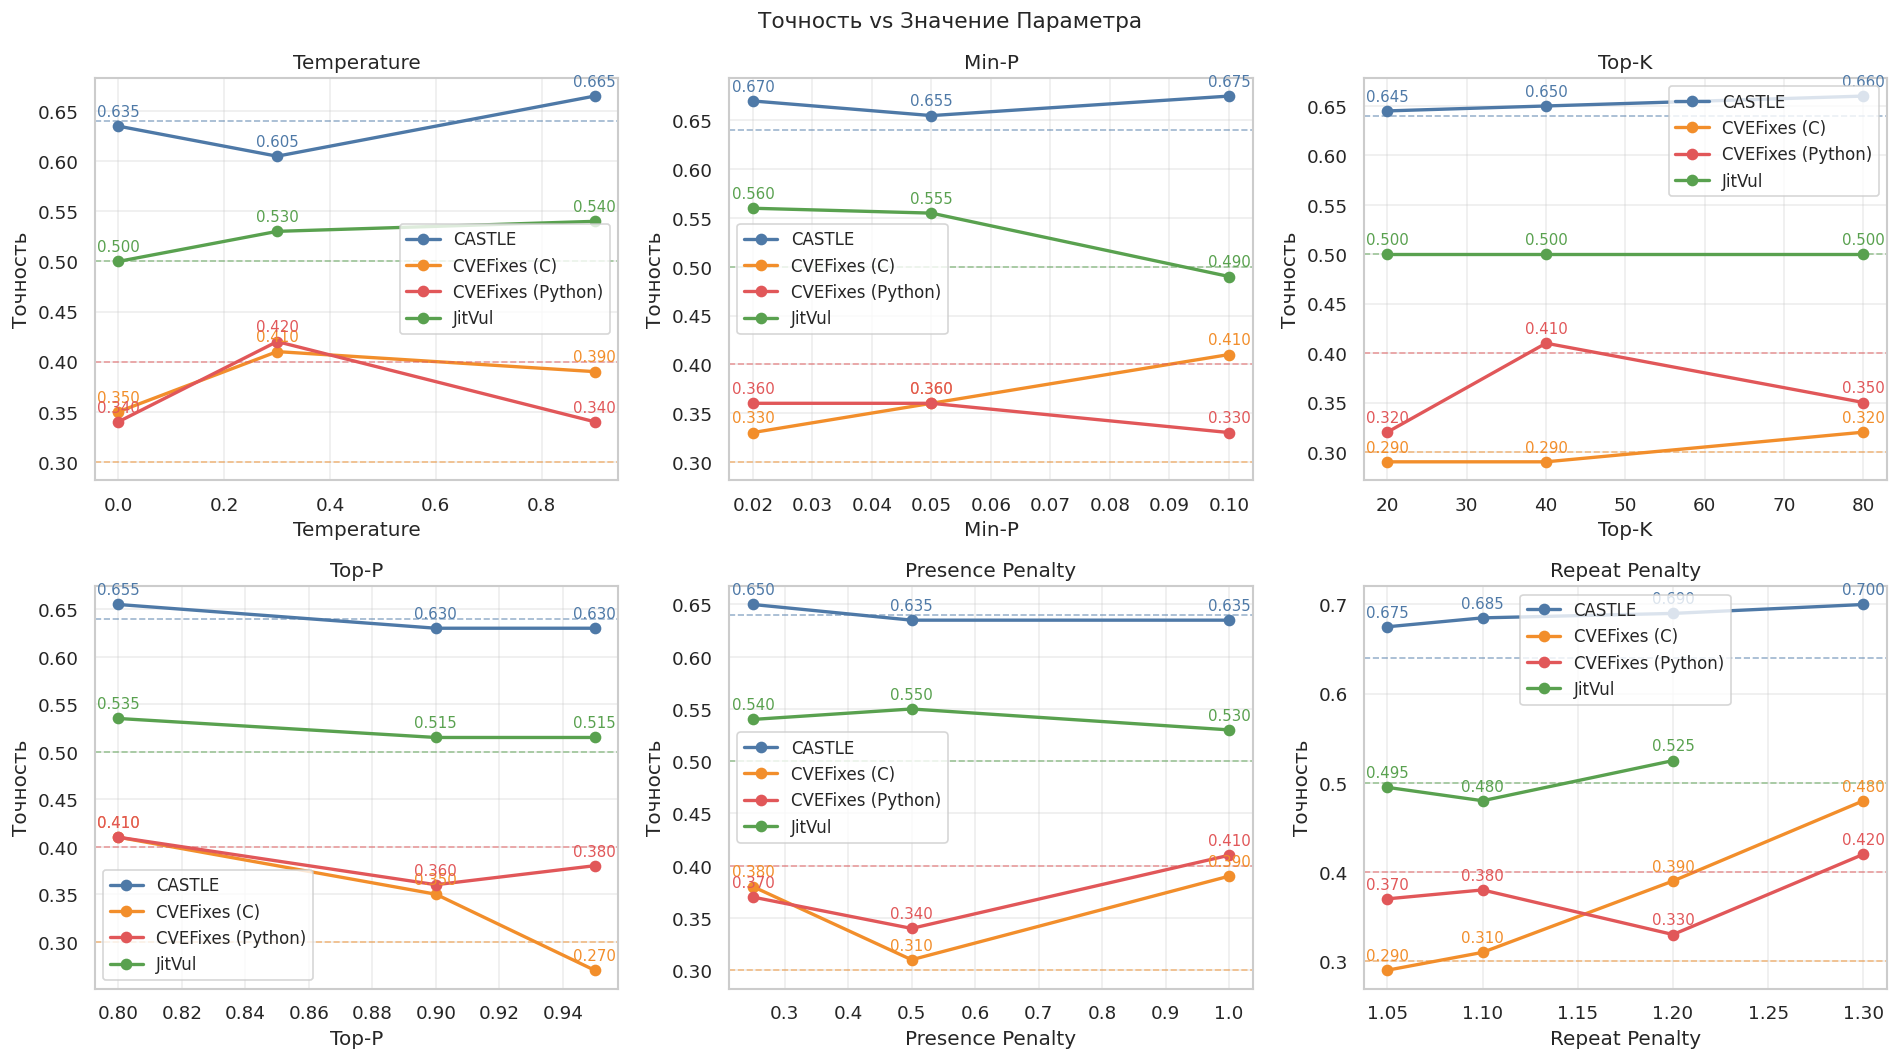

In [11]:
## Accuracy vs parameter value — 2x3 grid, one panel per parameter type
## Dashed horizontal lines = baseline accuracy per dataset

baseline_by_ds = df[df['param_type'] == 'baseline'].set_index('dataset')[['accuracy', 'FNR']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['accuracy'],
                marker='o', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        # Annotate each point with its config label
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['accuracy']:.3f}",
                        (row['param_value'], row['accuracy']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=9, color=DATASET_COLORS[ds])
        # Baseline reference line
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'accuracy'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('Точность')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('Точность vs Значение Параметра', fontsize=13)
fig.tight_layout()
plt.show()

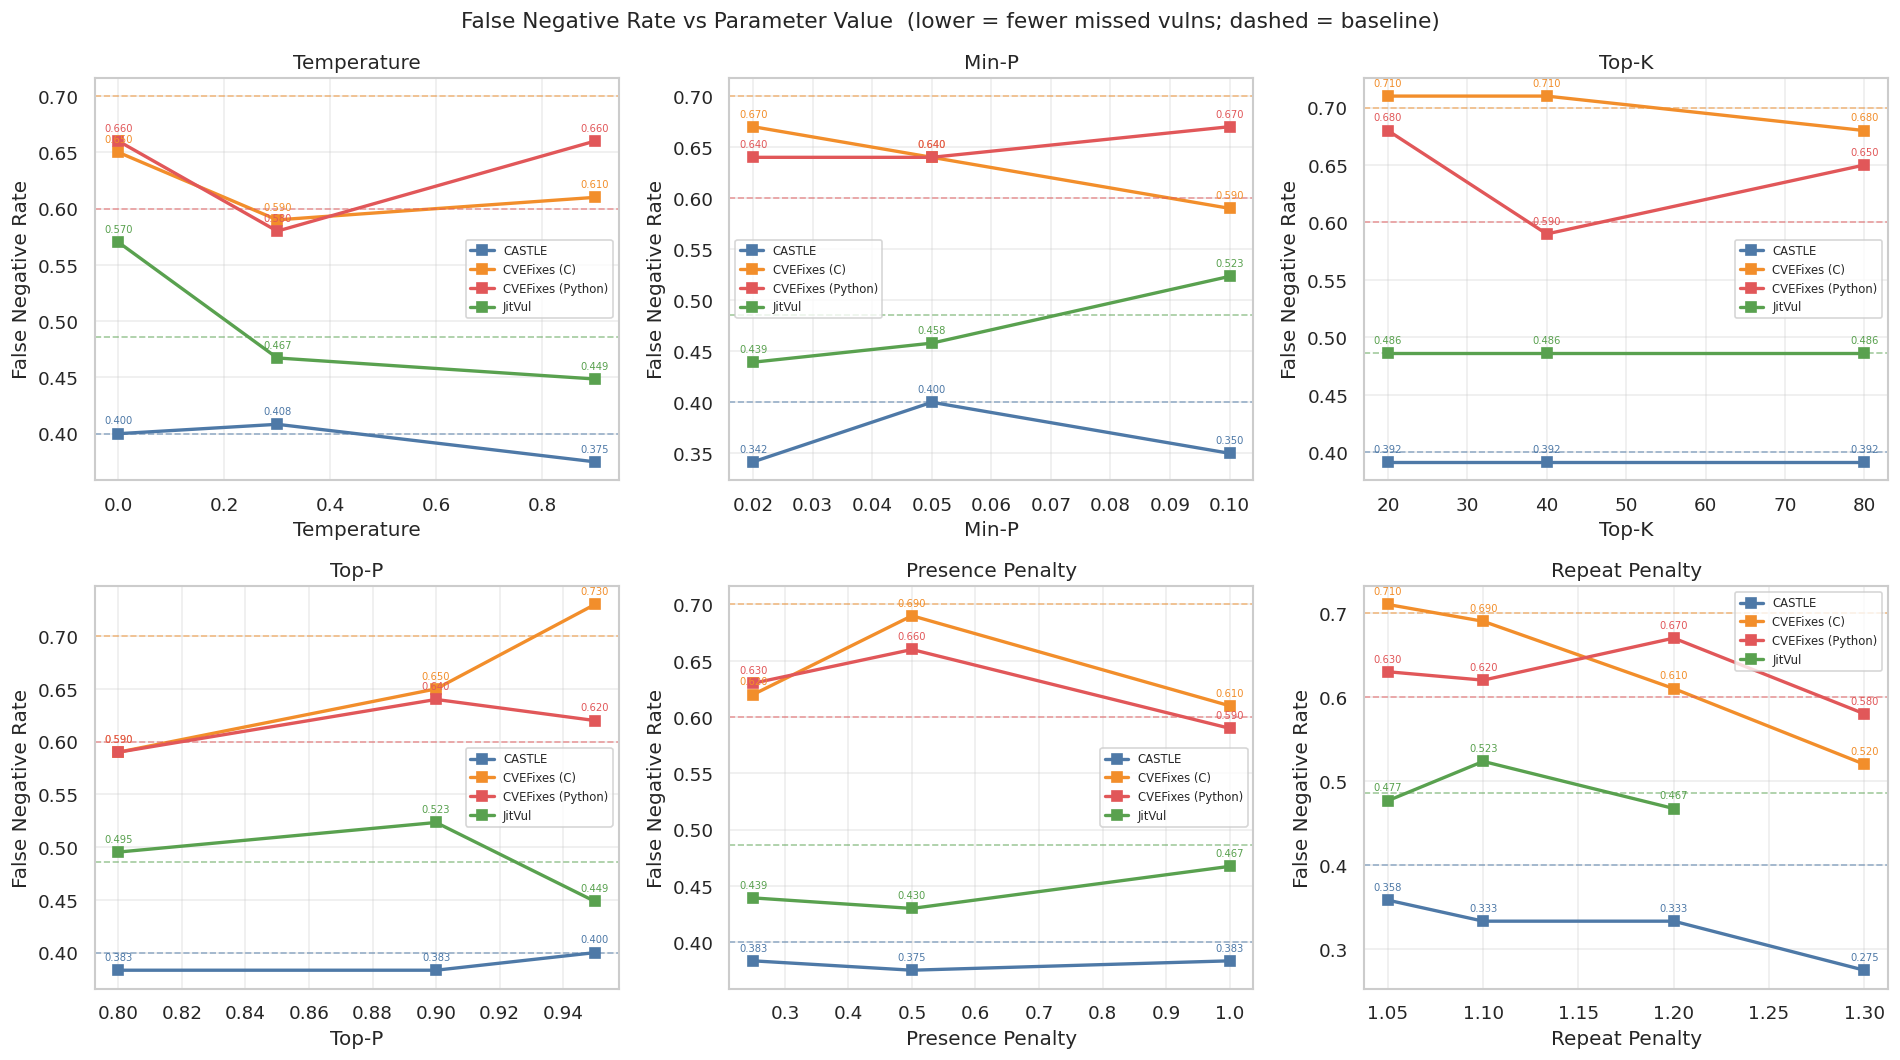

In [12]:
## False Negative Rate vs parameter value — same layout as accuracy chart
## Lower FNR = fewer missed vulnerabilities (better for security)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['FNR'],
                marker='s', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['FNR']:.3f}",
                        (row['param_value'], row['FNR']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=6, color=DATASET_COLORS[ds])
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'FNR'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('False Negative Rate')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('False Negative Rate vs Parameter Value  (lower = fewer missed vulns; dashed = baseline)',
             fontsize=13)
fig.tight_layout()
plt.show()

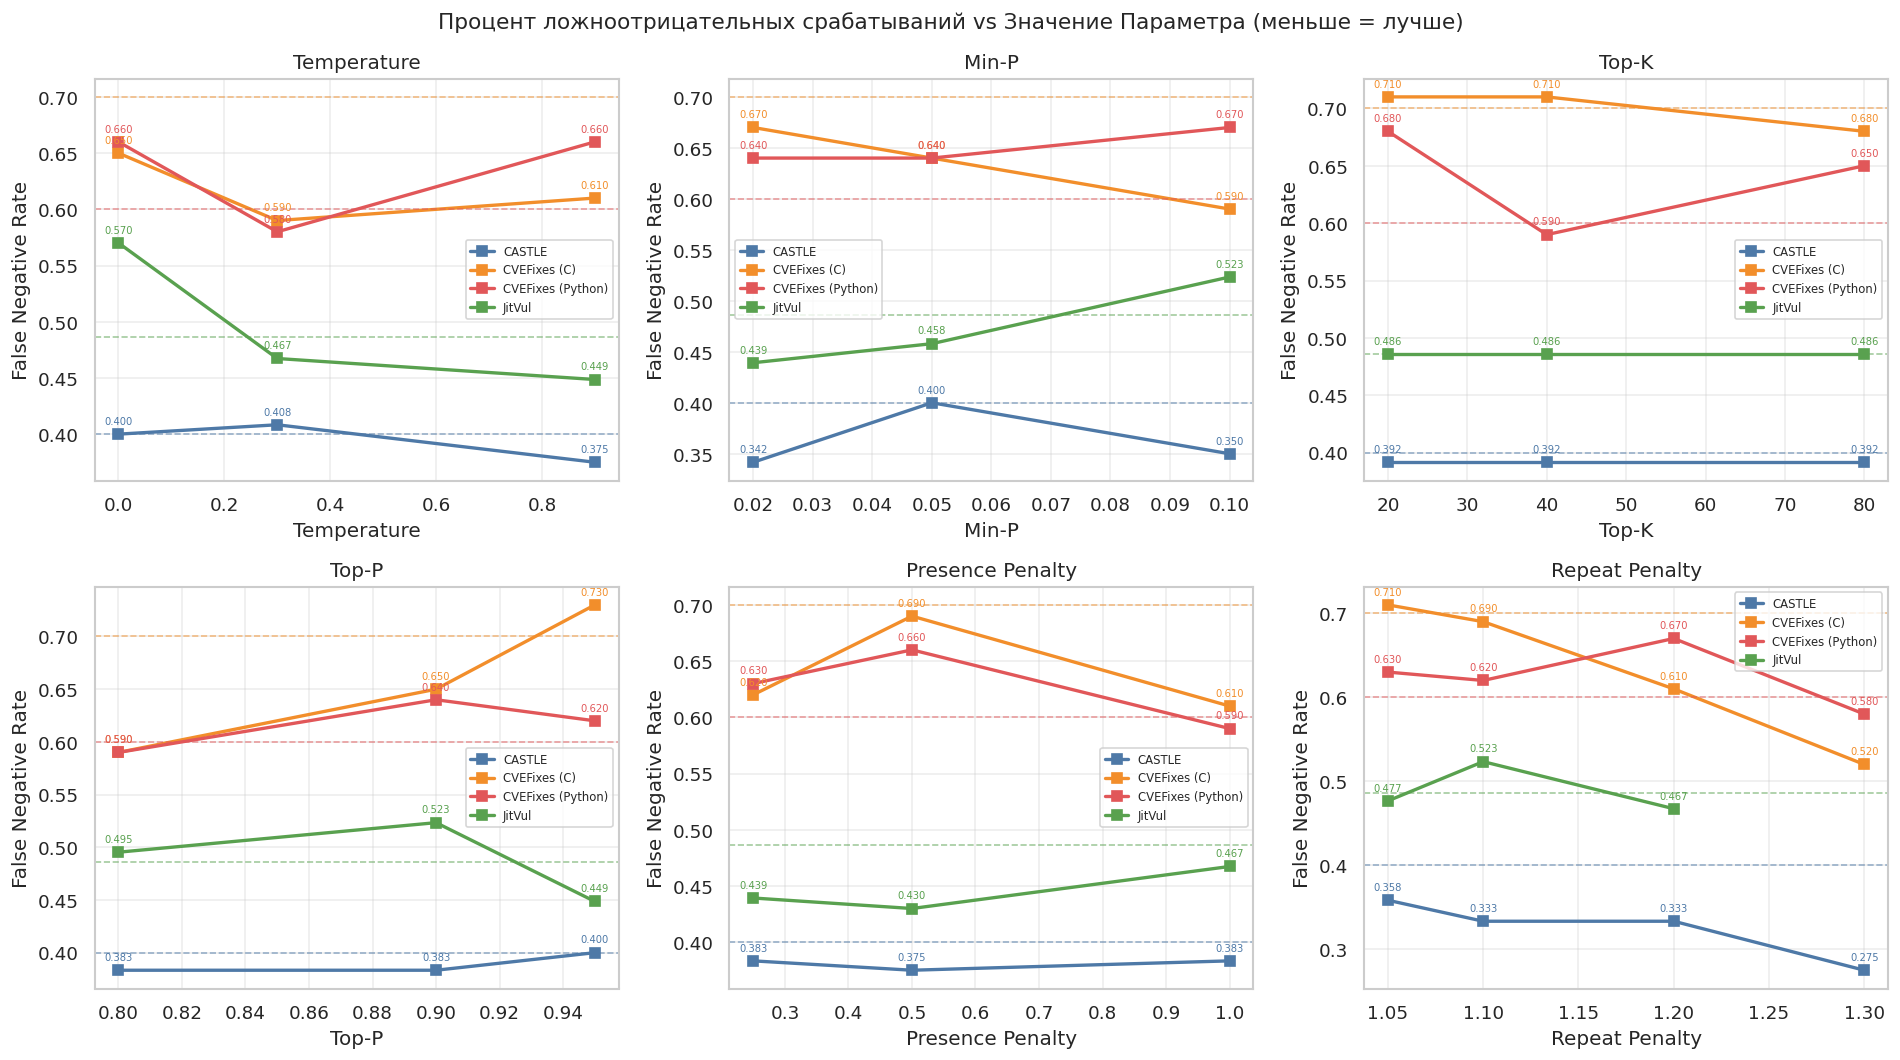

In [13]:
## False Negative Rate vs parameter value — same layout as accuracy chart
## Lower FNR = fewer missed vulnerabilities (better for security)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, param_type in zip(axes.flat, PARAM_TYPES_ORDERED):
    sub = df[df['param_type'] == param_type].sort_values('param_value')
    for ds in DATASETS_ORDERED:
        ds_sub = sub[sub['dataset'] == ds].sort_values('param_value')
        if ds_sub.empty:
            continue
        ax.plot(ds_sub['param_value'], ds_sub['FNR'],
                marker='s', linewidth=2, markersize=6,
                label=DATASET_DISPLAY[ds], color=DATASET_COLORS[ds])
        for _, row in ds_sub.iterrows():
            ax.annotate(f"{row['FNR']:.3f}",
                        (row['param_value'], row['FNR']),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=6, color=DATASET_COLORS[ds])
        if ds in baseline_by_ds.index:
            ax.axhline(baseline_by_ds.loc[ds, 'FNR'],
                       color=DATASET_COLORS[ds], linestyle='--', linewidth=1, alpha=0.55)

    ax.set_xlabel(PARAM_TYPE_DISPLAY[param_type])
    ax.set_ylabel('False Negative Rate')
    ax.set_title(PARAM_TYPE_DISPLAY[param_type])
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.35)

fig.suptitle('Процент ложноотрицательных срабатываний vs Значение Параметра (меньше = лучше)',
             fontsize=13)
fig.tight_layout()
plt.show()

## Delta from Baseline

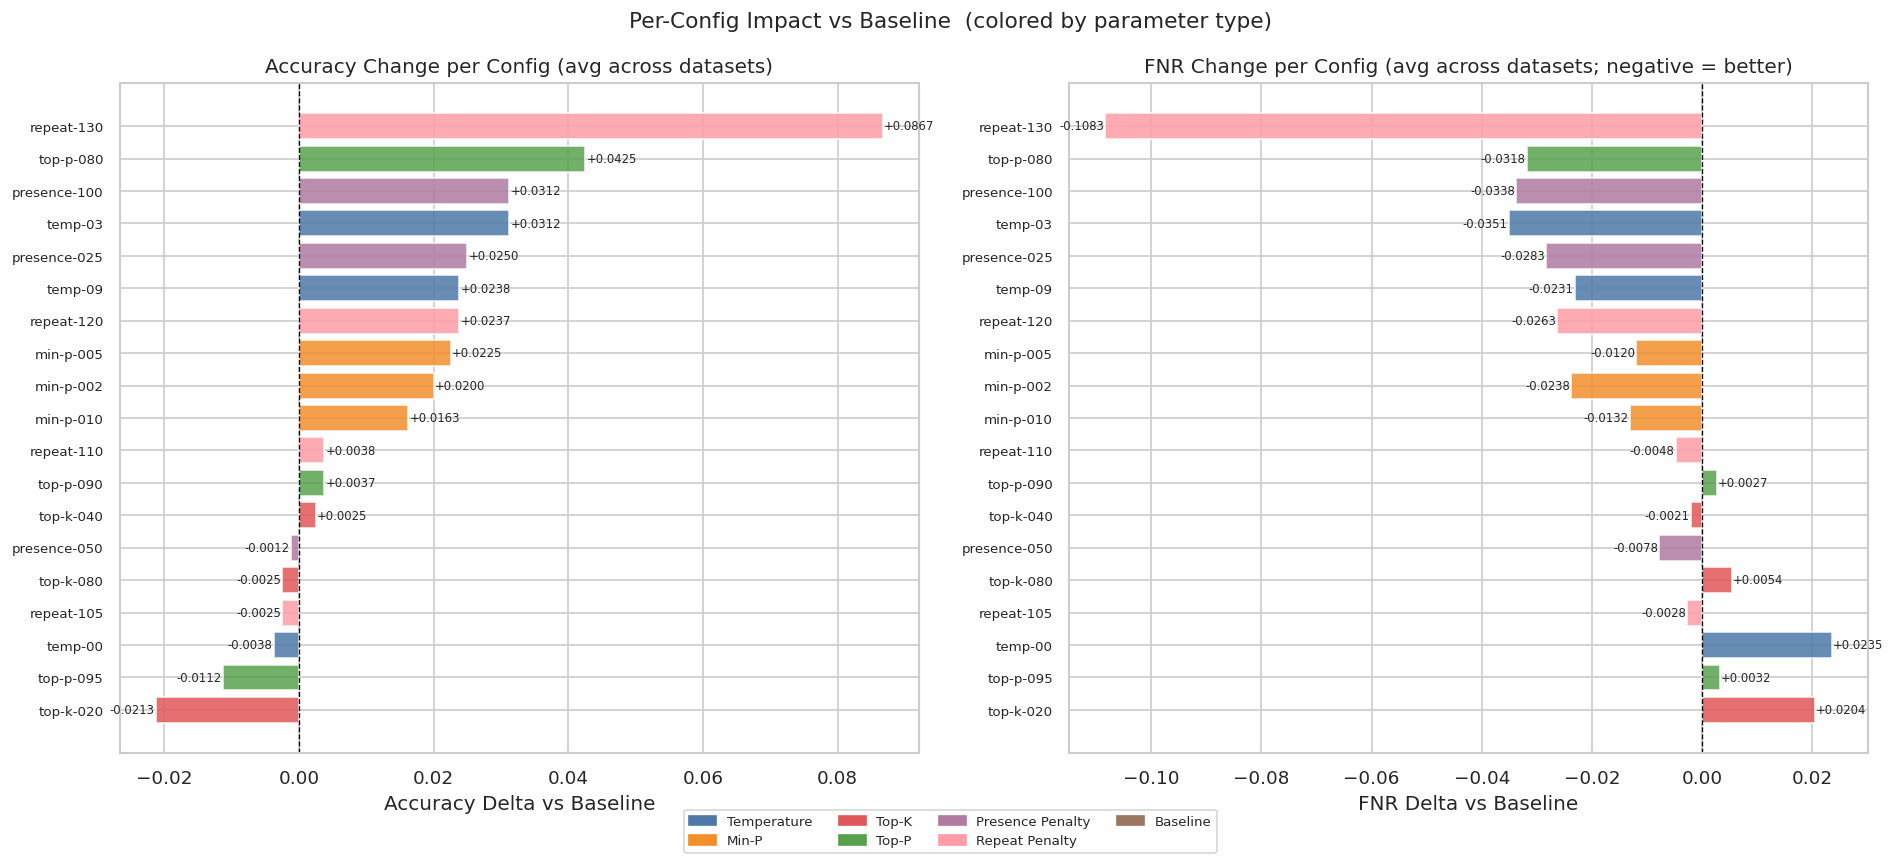

In [14]:
## Average accuracy delta per config (averaged across datasets) — horizontal bar chart

avg_delta = (
    df[df['param_type'] != 'baseline']
    .groupby('param_label')[['delta_acc', 'delta_fnr', 'delta_bacc', 'delta_mcc']]
    .mean()
    .reset_index()
)
avg_delta['param_type'] = avg_delta['param_label'].apply(
    lambda x: _parse_param('qwen3-4b-' + x)[0]
)
avg_delta = avg_delta.sort_values('delta_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (col, xlabel, title, flip) in zip(axes, [
    ('delta_acc', 'Accuracy Delta vs Baseline',
     'Accuracy Change per Config (avg across datasets)', False),
    ('delta_fnr', 'FNR Delta vs Baseline',
     'FNR Change per Config (avg across datasets; negative = better)', True),
]):
    colors = [
        PARAM_TYPE_COLORS.get(pt, '#aaa')
        for pt in avg_delta['param_type']
    ]
    ax.barh(avg_delta['param_label'], avg_delta[col], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=8)
    for i, (_, row) in enumerate(avg_delta.iterrows()):
        v = row[col]
        ax.text(v + (2e-4 if v >= 0 else -2e-4), i,
                f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=7)

# Legend by param type
patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Per-Config Impact vs Baseline  (colored by parameter type)', fontsize=13)
fig.tight_layout()
plt.show()

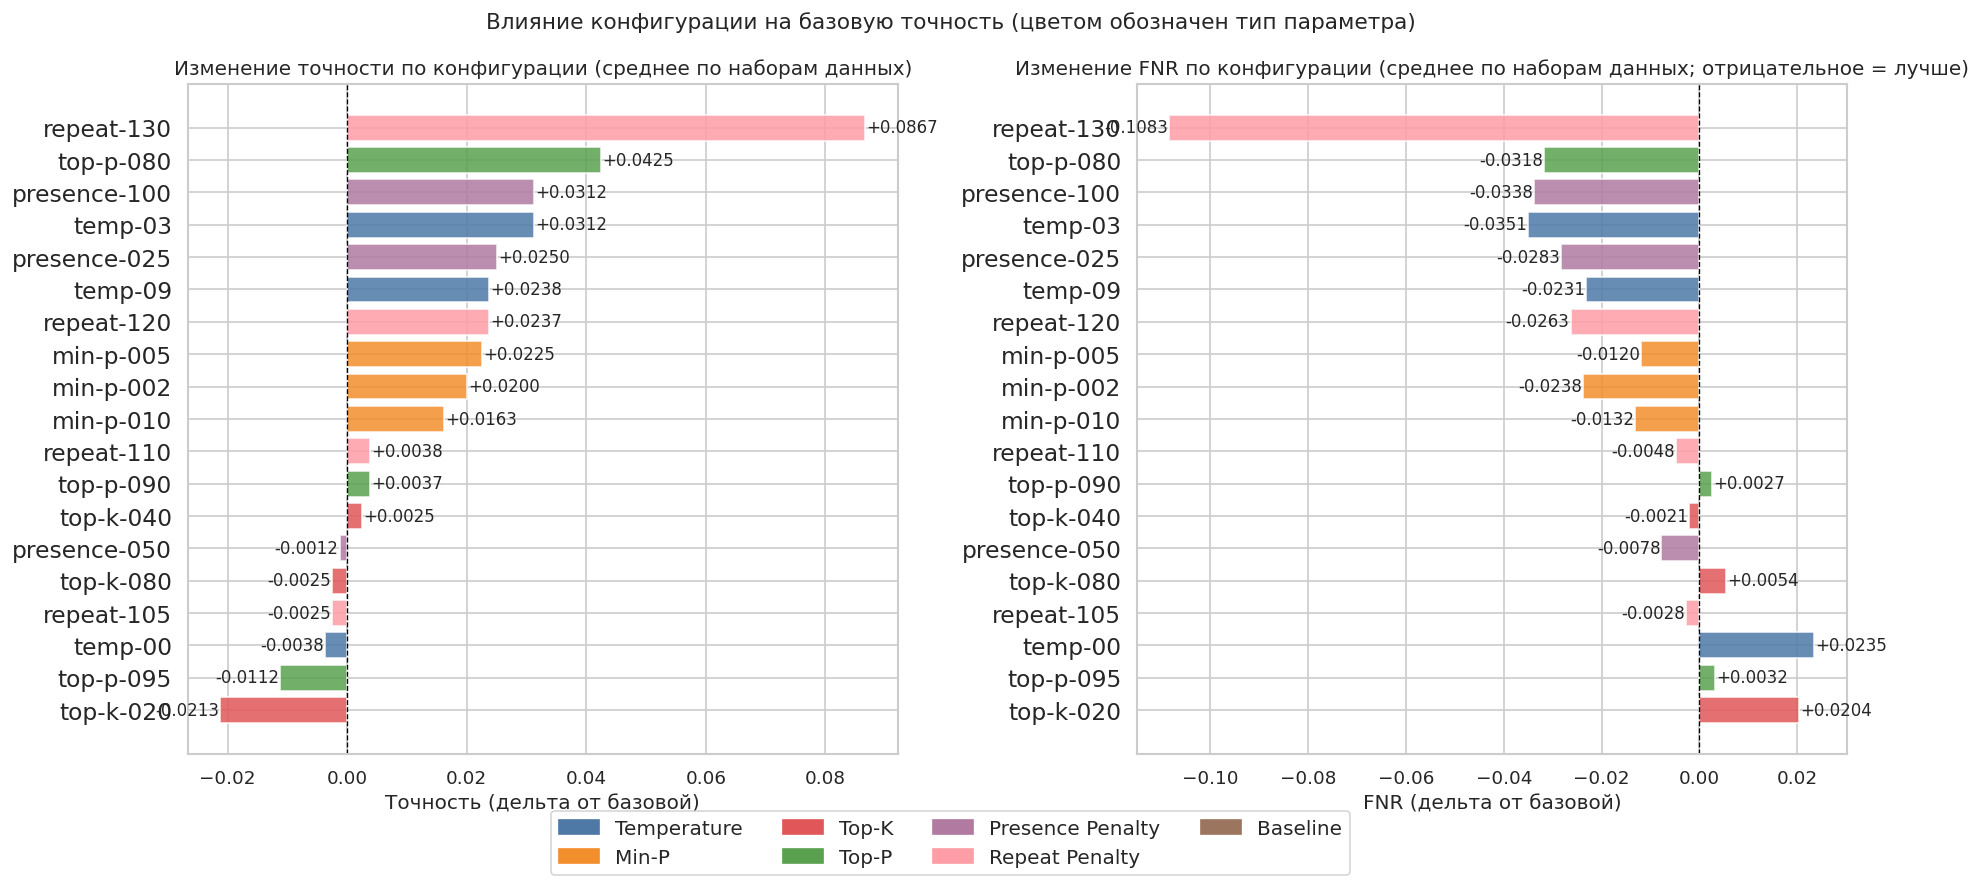

In [15]:
## Average accuracy delta per config (averaged across datasets) — horizontal bar chart

avg_delta = (
    df[df['param_type'] != 'baseline']
    .groupby('param_label')[['delta_acc', 'delta_fnr', 'delta_bacc', 'delta_mcc']]
    .mean()
    .reset_index()
)
avg_delta['param_type'] = avg_delta['param_label'].apply(
    lambda x: _parse_param('qwen3-4b-' + x)[0]
)
avg_delta = avg_delta.sort_values('delta_acc', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (col, xlabel, title, flip) in zip(axes, [
    ('delta_acc', 'Точность (дельта от базовой)',
     'Изменение точности по конфигурации (среднее по наборам данных)', False),
    ('delta_fnr', 'FNR (дельта от базовой)',
     'Изменение FNR по конфигурации (среднее по наборам данных; отрицательное = лучше)', True),
]):
    colors = [
        PARAM_TYPE_COLORS.get(pt, '#aaa')
        for pt in avg_delta['param_type']
    ]
    ax.barh(avg_delta['param_label'], avg_delta[col], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.tick_params(axis='y', labelsize=14)
    for i, (_, row) in enumerate(avg_delta.iterrows()):
        v = row[col]
        ax.text(v + (2e-4 if v >= 0 else -2e-4), i,
                f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10)

# Legend by param type
patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=12,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle('Влияние конфигурации на базовую точность (цветом обозначен тип параметра)', fontsize=13)
fig.tight_layout()
plt.show()

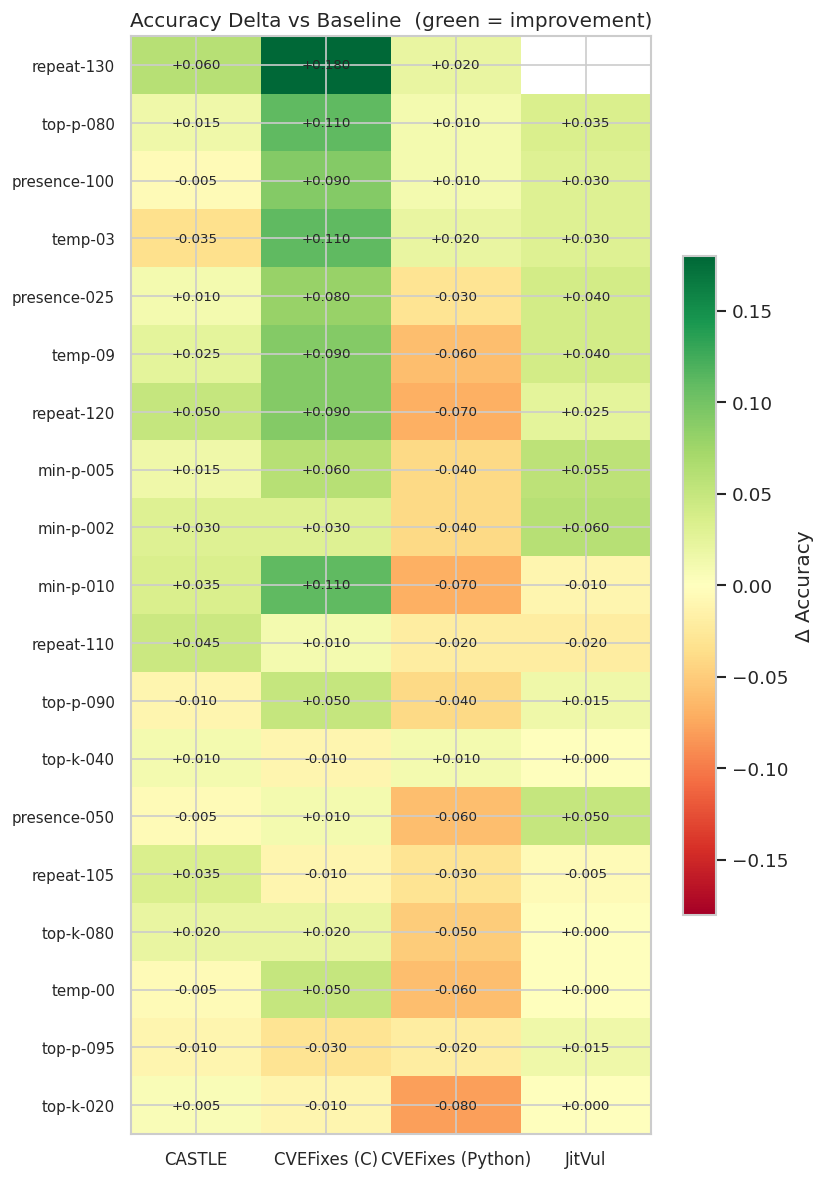

In [16]:
## Delta heatmap — accuracy change per config x dataset (green = improvement over baseline)

delta_pivot = (
    df[df['param_type'] != 'baseline']
    .pivot_table(index='param_label', columns='dataset', values='delta_acc', aggfunc='first')
    .reindex(columns=DATASETS_ORDERED)
)
delta_pivot = delta_pivot.loc[delta_pivot.mean(axis=1).sort_values(ascending=False).index]
delta_pivot.columns = [DATASET_DISPLAY[c] for c in delta_pivot.columns]

vmax = max(abs(float(np.nanmax(delta_pivot.values))),
           abs(float(np.nanmin(delta_pivot.values))), 0.03)

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(delta_pivot.values.astype(float), cmap='RdYlGn',
               vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(delta_pivot.columns)))
ax.set_xticklabels(delta_pivot.columns, fontsize=10)
ax.set_yticks(range(len(delta_pivot)))
ax.set_yticklabels(delta_pivot.index, fontsize=9)
ax.set_title('Accuracy Delta vs Baseline  (green = improvement)', fontsize=12)
for i in range(len(delta_pivot)):
    for j in range(len(delta_pivot.columns)):
        v = delta_pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.6, label='\u0394 Accuracy')
fig.tight_layout()
plt.show()

## Best Configuration per Parameter Type

In [17]:
## For each parameter type x dataset: which value gives best accuracy?

best_rows = []
for param_type in PARAM_TYPES_ORDERED:
    for ds in DATASETS_ORDERED:
        sub = df[(df['param_type'] == param_type) & (df['dataset'] == ds)]
        if sub.empty:
            continue
        best = sub.loc[sub['accuracy'].idxmax()]
        worst = sub.loc[sub['accuracy'].idxmin()]
        best_rows.append({
            'Param Type':     PARAM_TYPE_DISPLAY[param_type],
            'Dataset':        DATASET_DISPLAY[ds],
            'Best Value':     best['param_value'],
            'Best Config':    best['param_label'],
            'Best Accuracy':  best['accuracy'],
            'Baseline Acc':   best['bl_acc'],
            'Best Delta':     best['delta_acc'],
            'Worst Value':    worst['param_value'],
            'Worst Accuracy': worst['accuracy'],
            'Worst Delta':    worst['delta_acc'],
            'Best FNR':       best['FNR'],
            'Baseline FNR':   best['bl_fnr'],
        })

best_df = pd.DataFrame(best_rows)

display(
    best_df.style
    .background_gradient(subset=['Best Delta', 'Worst Delta'], cmap='RdYlGn', axis=None,
                         vmin=-0.08, vmax=0.08)
    .format({
        'Best Value':     '{:.3f}',
        'Best Accuracy':  '{:.3f}',
        'Baseline Acc':   '{:.3f}',
        'Best Delta':     '{:+.3f}',
        'Worst Value':    '{:.3f}',
        'Worst Accuracy': '{:.3f}',
        'Worst Delta':    '{:+.3f}',
        'Best FNR':       '{:.3f}',
        'Baseline FNR':   '{:.3f}',
    })
)

,Param Type,Dataset,Best Value,Best Config,Best Accuracy,Baseline Acc,Best Delta,Worst Value,Worst Accuracy,Worst Delta,Best FNR,Baseline FNR
0,Temperature,CASTLE,0.900,temp-09,0.665,0.640,+0.025,0.300,0.605,-0.035,0.375,0.400
1,Temperature,CVEFixes (C),0.300,temp-03,0.410,0.300,+0.110,0.000,0.350,+0.050,0.590,0.700
2,Temperature,CVEFixes (Python),0.300,temp-03,0.420,0.400,+0.020,0.000,0.340,-0.060,0.580,0.600
3,Temperature,JitVul,0.900,temp-09,0.540,0.500,+0.040,0.000,0.500,+0.000,0.449,0.486
4,Min-P,CASTLE,0.100,min-p-010,0.675,0.640,+0.035,0.050,0.655,+0.015,0.350,0.400
5,Min-P,CVEFixes (C),0.100,min-p-010,0.410,0.300,+0.110,0.020,0.330,+0.030,0.590,0.700
6,Min-P,CVEFixes (Python),0.020,min-p-002,0.360,0.400,-0.040,0.100,0.330,-0.070,0.640,0.600
7,Min-P,JitVul,0.020,min-p-002,0.560,0.500,+0.060,0.100,0.490,-0.010,0.439,0.486
8,Top-K,CASTLE,80.000,top-k-080,0.660,0.640,+0.020,20.000,0.645,+0.005,0.392,0.400
9,Top-K,CVEFixes (C),80.000,top-k-080,0.320,0.300,+0.020,20.000,0.290,-0.010,0.680,0.700


## Cross-Dataset Consistency

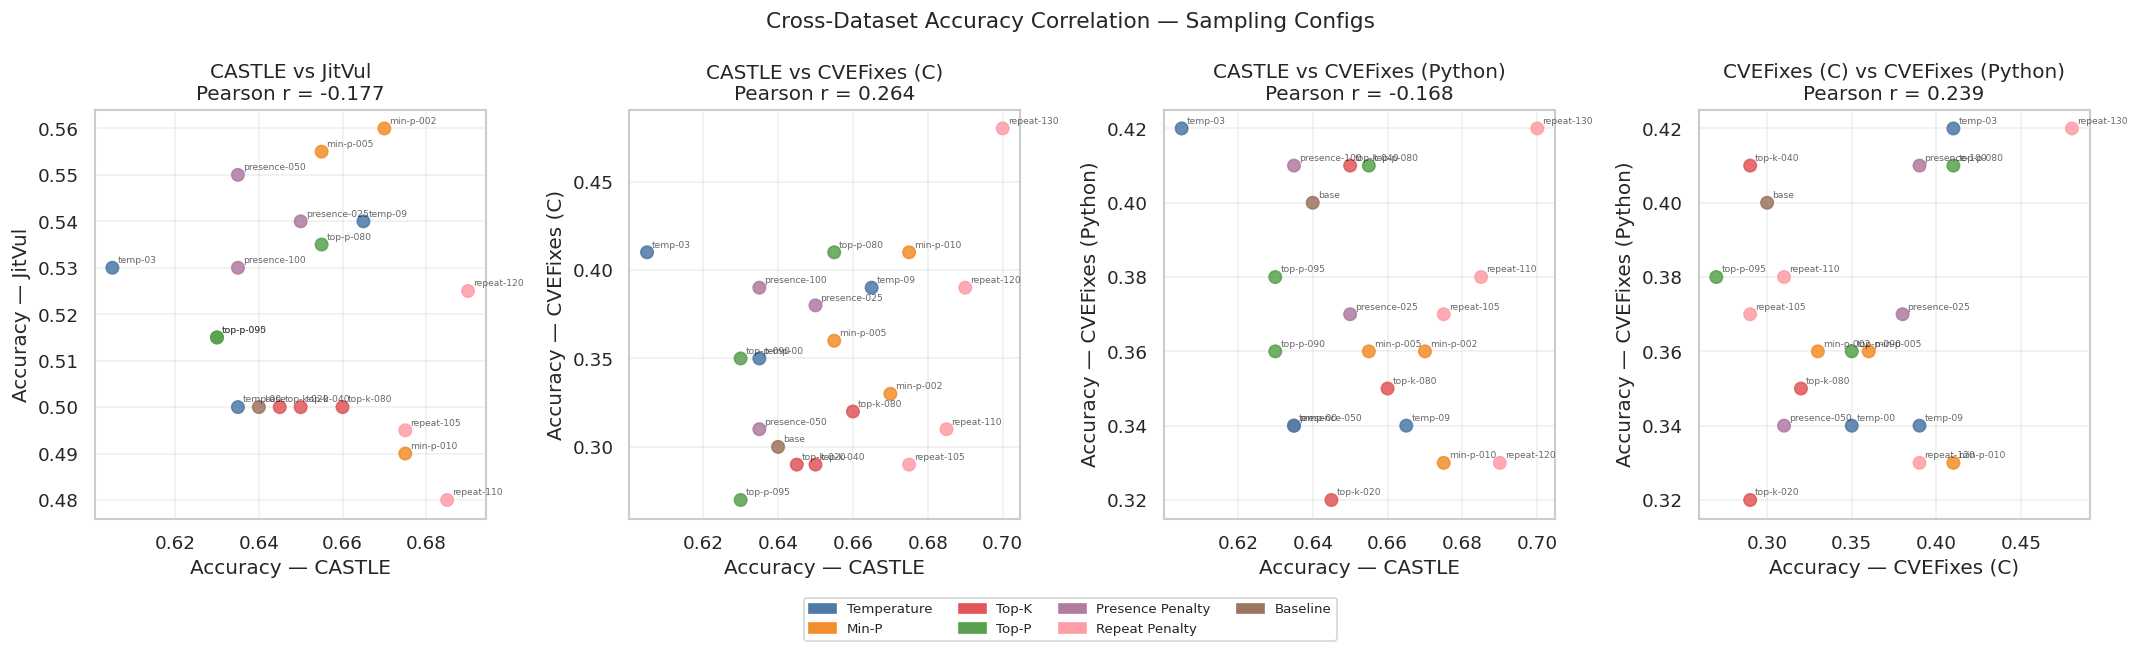

In [18]:
## Cross-dataset scatter — does a config that helps on one dataset also help on another?
## Each point = one sampling config; color = parameter type

CORR_PAIRS = [
    ('castle',        'jitvul'),
    ('castle',        'cvefixes_c'),
    ('castle',        'cvefixes_python'),
    ('cvefixes_c',    'cvefixes_python'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (ds1, ds2) in zip(axes, CORR_PAIRS):
    s1 = df[df['dataset'] == ds1][['model_name', 'param_type', 'accuracy', 'param_label']].rename(
        columns={'accuracy': 'acc1'})
    s2 = df[df['dataset'] == ds2][['model_name', 'accuracy']].rename(
        columns={'accuracy': 'acc2'})
    merged = s1.merge(s2, on='model_name').dropna(subset=['acc1', 'acc2'])
    if merged.empty:
        continue

    pt_colors = [PARAM_TYPE_COLORS.get(pt, '#9c755f') for pt in merged['param_type']]
    ax.scatter(merged['acc1'], merged['acc2'], c=pt_colors, s=55, alpha=0.85, zorder=3)

    for _, row in merged.iterrows():
        ax.annotate(row['param_label'], (row['acc1'], row['acc2']),
                    fontsize=5.5, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    r = float(np.corrcoef(merged['acc1'], merged['acc2'])[0, 1])
    ax.set_xlabel(f'Accuracy — {DATASET_DISPLAY[ds1]}')
    ax.set_ylabel(f'Accuracy — {DATASET_DISPLAY[ds2]}')
    ax.set_title(f'{DATASET_DISPLAY[ds1]} vs {DATASET_DISPLAY[ds2]}\nPearson r = {r:.3f}')
    ax.grid(True, alpha=0.3)

patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Cross-Dataset Accuracy Correlation — Sampling Configs', fontsize=13)
fig.tight_layout()
plt.show()

## Thinking vs Non-Thinking Comparison

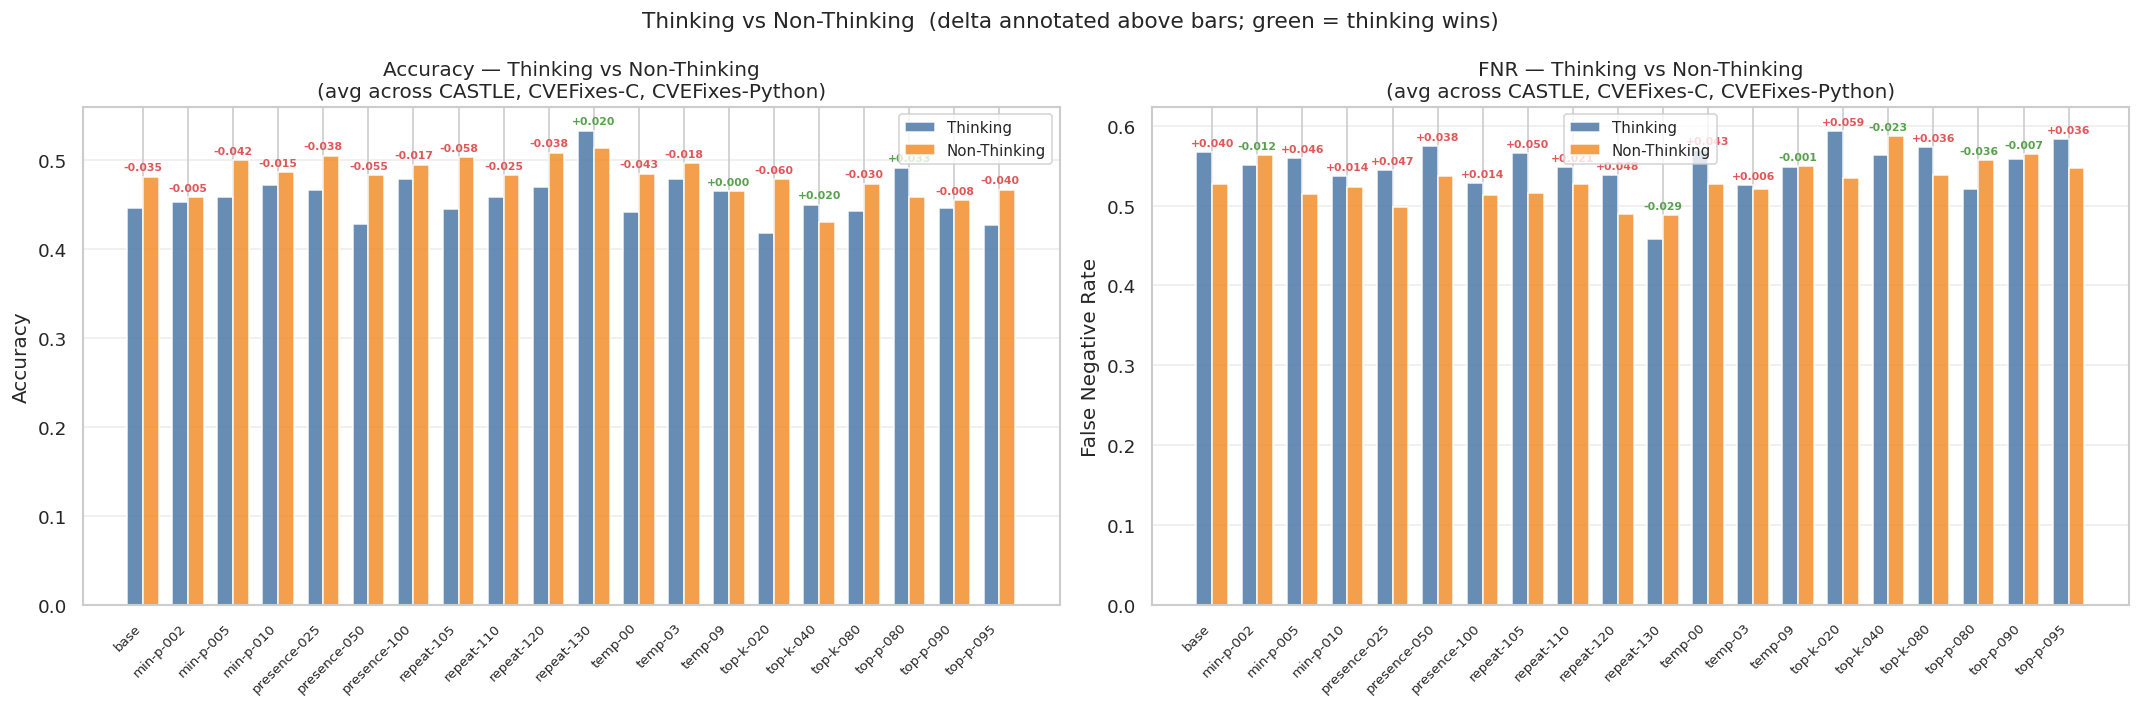

,Config,Param Type,Acc (Think),Acc (NT),Δ Acc (T−NT),FNR (Think),FNR (NT),Δ FNR (T−NT)
0,base,baseline,0.447,0.482,-0.035,0.567,0.527,+0.040
1,min-p-002,min_p,0.453,0.458,-0.005,0.551,0.563,-0.012
2,min-p-005,min_p,0.458,0.500,-0.042,0.560,0.514,+0.046
3,min-p-010,min_p,0.472,0.487,-0.015,0.537,0.523,+0.014
4,presence-025,presence_penalty,0.467,0.505,-0.038,0.544,0.498,+0.047
5,presence-050,presence_penalty,0.428,0.483,-0.055,0.575,0.537,+0.038
6,presence-100,presence_penalty,0.478,0.495,-0.017,0.528,0.513,+0.014
7,repeat-105,repeat_penalty,0.445,0.503,-0.058,0.566,0.516,+0.050
8,repeat-110,repeat_penalty,0.458,0.483,-0.025,0.548,0.527,+0.021
9,repeat-120,repeat_penalty,0.470,0.508,-0.038,0.538,0.490,+0.048


In [19]:
## Thinking vs non-thinking: average accuracy and FNR per config
## Datasets with both modes: CASTLE, CVEFixes (C), CVEFixes (Python)
## JitVul has only thinking data and is excluded from this comparison.

SHARED_DATASETS = ['castle', 'cvefixes_c', 'cvefixes_python']

# Average over shared datasets for each (param_suffix, thinking)
think_avg = (
    df[df['dataset'].isin(SHARED_DATASETS)]
    .groupby('param_suffix')[['accuracy', 'FNR', 'delta_acc', 'delta_fnr']]
    .mean()
    .rename(columns={'accuracy': 'acc_t', 'FNR': 'fnr_t',
                     'delta_acc': 'dacc_t', 'delta_fnr': 'dfnr_t'})
)
nt_avg = (
    df_nt[df_nt['dataset'].isin(SHARED_DATASETS)]
    .groupby('param_suffix')[['accuracy', 'FNR', 'delta_acc', 'delta_fnr']]
    .mean()
    .rename(columns={'accuracy': 'acc_nt', 'FNR': 'fnr_nt',
                     'delta_acc': 'dacc_nt', 'delta_fnr': 'dfnr_nt'})
)
cmp = think_avg.join(nt_avg, how='inner').reset_index()
cmp['param_type'] = cmp['param_suffix'].apply(lambda x: _parse_param('qwen3-4b-' + x)[0])
cmp = cmp.sort_values(['param_type', 'param_suffix']).reset_index(drop=True)
cmp['acc_delta_t_vs_nt']  = cmp['acc_t']  - cmp['acc_nt']   # positive = thinking wins
cmp['fnr_delta_t_vs_nt']  = cmp['fnr_t']  - cmp['fnr_nt']   # negative = thinking wins (lower FNR)

x      = np.arange(len(cmp))
width  = 0.35
labels = cmp['param_suffix'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (col_t, col_nt, ylabel, title, lower_better) in zip(axes, [
    ('acc_t',  'acc_nt',  'Accuracy',           'Accuracy — Thinking vs Non-Thinking', False),
    ('fnr_t',  'fnr_nt',  'False Negative Rate', 'FNR — Thinking vs Non-Thinking',     True),
]):
    bars_t  = ax.bar(x - width / 2, cmp[col_t],  width, label='Thinking',     color=THINKING_COLOR, alpha=0.85)
    bars_nt = ax.bar(x + width / 2, cmp[col_nt], width, label='Non-Thinking', color=NT_COLOR,       alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title + '\n(avg across CASTLE, CVEFixes-C, CVEFixes-Python)')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.35)
    # Annotate delta
    for i, row in cmp.iterrows():
        delta = row[col_t] - row[col_nt]
        sign  = '+' if delta >= 0 else ''
        color = ('#59a14f' if (not lower_better and delta >= 0) or (lower_better and delta <= 0)
                 else '#e15759')
        ax.text(i, max(row[col_t], row[col_nt]) + 0.005,
                f'{sign}{delta:.3f}', ha='center', va='bottom', fontsize=6.5, color=color,
                fontweight='bold')

fig.suptitle('Thinking vs Non-Thinking  (delta annotated above bars; green = thinking wins)',
             fontsize=13)
fig.tight_layout()
plt.show()

# Summary table
display(
    cmp[['param_suffix', 'param_type', 'acc_t', 'acc_nt', 'acc_delta_t_vs_nt',
         'fnr_t', 'fnr_nt', 'fnr_delta_t_vs_nt']]
    .rename(columns={
        'param_suffix':        'Config',
        'param_type':          'Param Type',
        'acc_t':               'Acc (Think)',
        'acc_nt':              'Acc (NT)',
        'acc_delta_t_vs_nt':   'Δ Acc (T−NT)',
        'fnr_t':               'FNR (Think)',
        'fnr_nt':              'FNR (NT)',
        'fnr_delta_t_vs_nt':   'Δ FNR (T−NT)',
    })
    .style
    .background_gradient(subset=['Δ Acc (T−NT)'],  cmap='RdYlGn', axis=0, vmin=-0.1, vmax=0.1)
    .background_gradient(subset=['Δ FNR (T−NT)'],  cmap='RdYlGn_r', axis=0, vmin=-0.1, vmax=0.1)
    .format({
        'Acc (Think)':   '{:.3f}',
        'Acc (NT)':      '{:.3f}',
        'Δ Acc (T−NT)':  '{:+.3f}',
        'FNR (Think)':   '{:.3f}',
        'FNR (NT)':      '{:.3f}',
        'Δ FNR (T−NT)':  '{:+.3f}',
    })
)

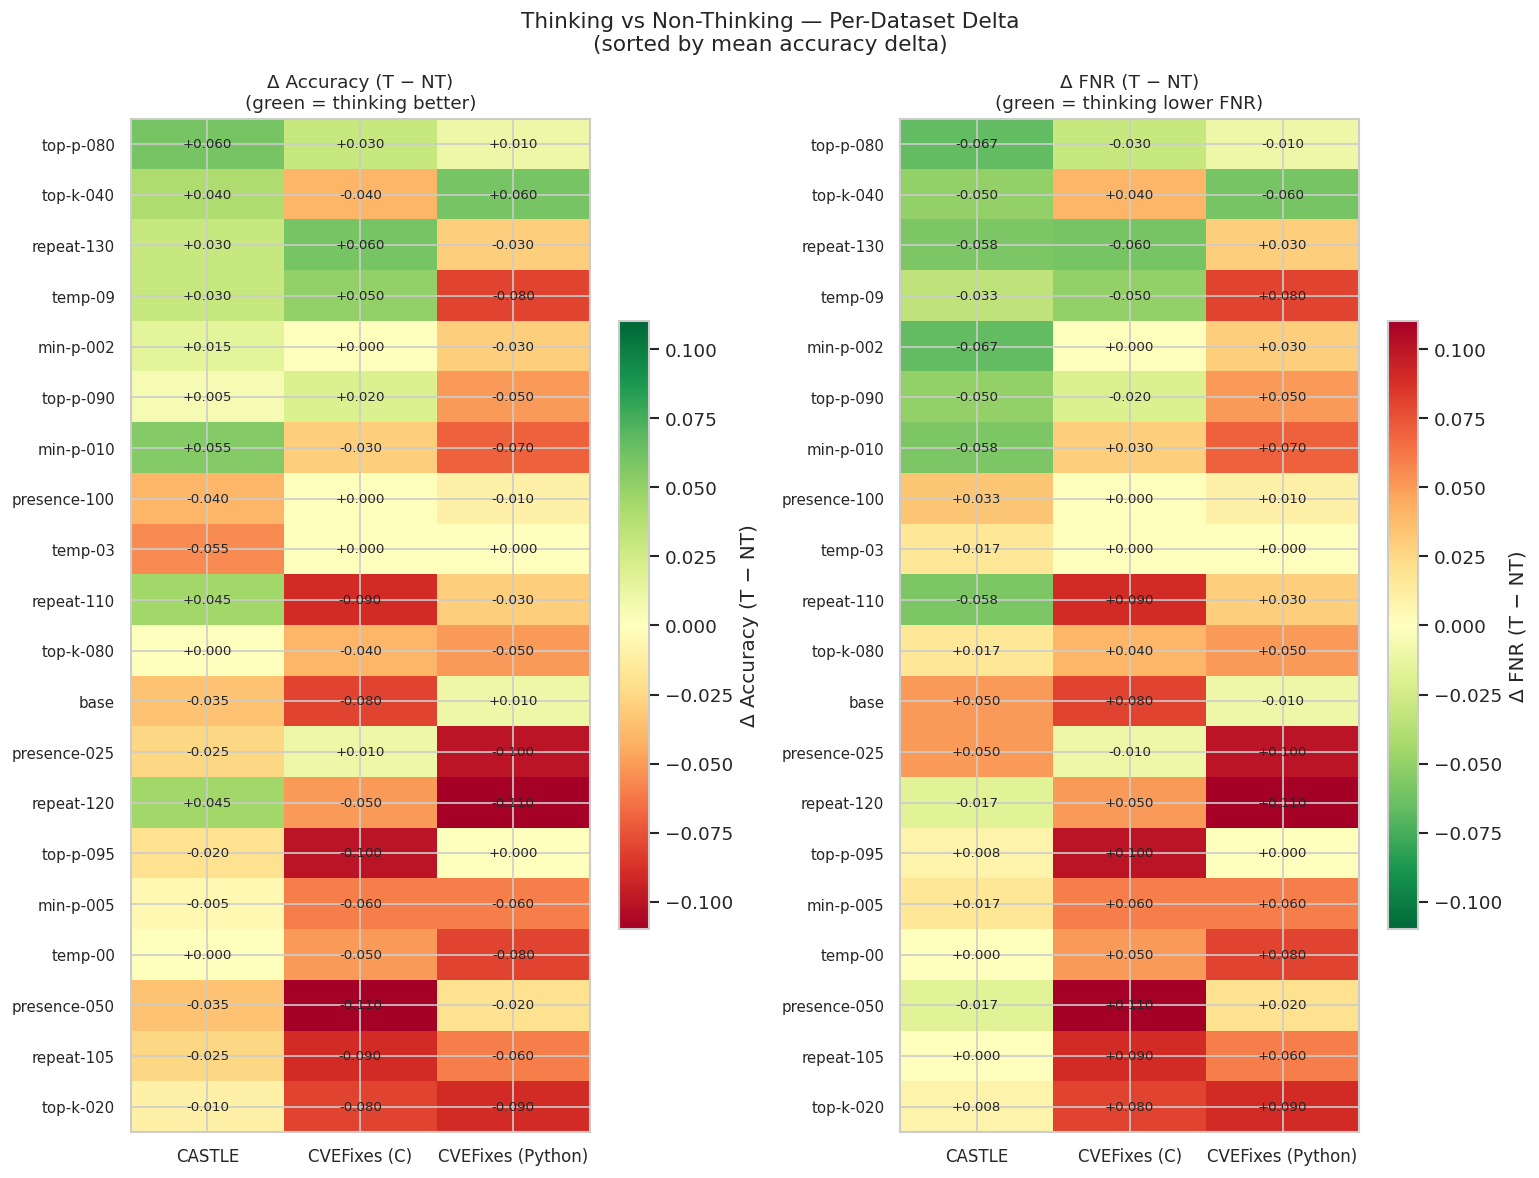

In [20]:
## Per-dataset accuracy and FNR heatmaps: Thinking − Non-Thinking delta
## Green = thinking is better on that metric for that config/dataset

# Build accuracy and FNR delta matrices (thinking - non-thinking)
think_ds = (
    df[df['dataset'].isin(SHARED_DATASETS)]
    .pivot_table(index='param_suffix', columns='dataset', values=['accuracy', 'FNR'], aggfunc='first')
)
nt_ds = (
    df_nt[df_nt['dataset'].isin(SHARED_DATASETS)]
    .pivot_table(index='param_suffix', columns='dataset', values=['accuracy', 'FNR'], aggfunc='first')
)
# Align indices
common_configs = think_ds.index.intersection(nt_ds.index)
think_ds = think_ds.loc[common_configs]
nt_ds    = nt_ds.loc[common_configs]

delta_acc  = (think_ds['accuracy'] - nt_ds['accuracy'])[SHARED_DATASETS]
delta_fnr  = (think_ds['FNR']      - nt_ds['FNR']     )[SHARED_DATASETS]

# Sort configs by mean accuracy delta descending
sort_order = delta_acc.mean(axis=1).sort_values(ascending=False).index
delta_acc  = delta_acc.loc[sort_order]
delta_fnr  = delta_fnr.loc[sort_order]

col_labels = [DATASET_DISPLAY[c] for c in SHARED_DATASETS]
vmax_acc = max(abs(float(np.nanmax(delta_acc.values))), abs(float(np.nanmin(delta_acc.values))), 0.03)
vmax_fnr = max(abs(float(np.nanmax(delta_fnr.values))), abs(float(np.nanmin(delta_fnr.values))), 0.03)

fig, axes = plt.subplots(1, 2, figsize=(13, 10))

for ax, mat, vmax, cmap, label, sign_help in [
    (axes[0], delta_acc, vmax_acc, 'RdYlGn',   'Δ Accuracy (T − NT)',   'green = thinking better'),
    (axes[1], delta_fnr, vmax_fnr, 'RdYlGn_r', 'Δ FNR (T − NT)',       'green = thinking lower FNR'),
]:
    im = ax.imshow(mat.values.astype(float), cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_title(f'{label}\n({sign_help})', fontsize=11)
    for i in range(len(mat)):
        for j in range(len(col_labels)):
            v = mat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:+.3f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.6, label=label)

fig.suptitle('Thinking vs Non-Thinking — Per-Dataset Delta\n(sorted by mean accuracy delta)',
             fontsize=13)
fig.tight_layout()
plt.show()

## Token Usage

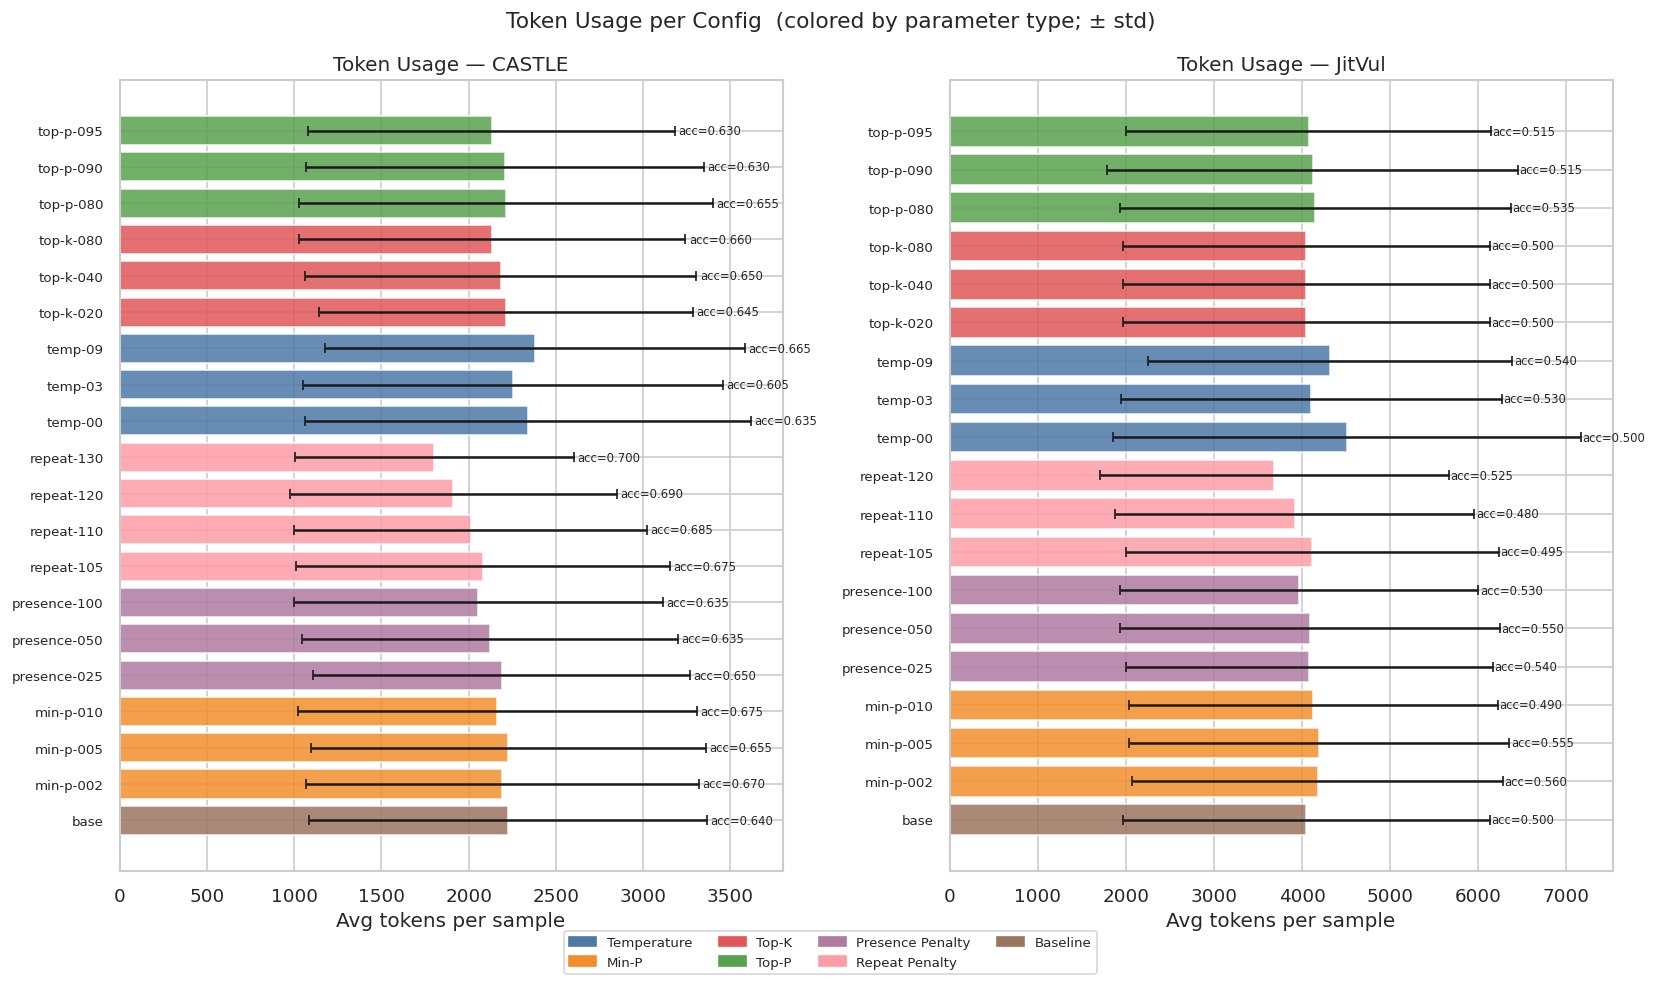

In [21]:
## Token usage per config, colored by parameter type — castle and jitvul (200 samples each)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, ds in zip(axes, ['castle', 'jitvul']):
    sub = (
        df[df['dataset'] == ds]
        .sort_values(['param_type', 'param_value'])
        .reset_index(drop=True)
    )
    colors = [PARAM_TYPE_COLORS.get(pt, '#9c755f') for pt in sub['param_type']]
    ax.barh(sub['param_label'], sub['tokens_avg'], xerr=sub['tokens_std'],
            color=colors, alpha=0.85, capsize=3)
    ax.set_xlabel('Avg tokens per sample')
    ax.set_title(f'Token Usage — {DATASET_DISPLAY[ds]}')
    ax.tick_params(axis='y', labelsize=8)
    # Add accuracy annotation at end of each bar
    for _, row in sub.iterrows():
        ax.text(row['tokens_avg'] + (row['tokens_std'] if not np.isnan(row['tokens_std']) else 0) + 20,
                sub.index[sub['param_label'] == row['param_label']].tolist()[0],
                f"acc={row['accuracy']:.3f}", va='center', fontsize=7)

patches = [mpatches.Patch(color=PARAM_TYPE_COLORS[pt], label=PARAM_TYPE_DISPLAY[pt])
           for pt in PARAM_TYPES_ORDERED]
patches.append(mpatches.Patch(color='#9c755f', label='Baseline'))
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Token Usage per Config  (colored by parameter type; ± std)', fontsize=13)
fig.tight_layout()
plt.show()

## Full Summary Table

In [22]:
## Styled summary — all aggregated configs, sorted by dataset then accuracy descending

SUMMARY_COLS = [
    'param_label', 'dataset_label',
    'accuracy', 'precision', 'recall', 'f1', 'specificity',
    'FNR', 'FPR', 'balanced_accuracy', 'MCC', 'youden_j',
    'delta_acc', 'delta_fnr',
    'TP', 'TN', 'FP', 'FN',
    'tokens_avg', 'time_avg', 'total_samples', 'n_runs',
]

summary = (
    df[SUMMARY_COLS]
    .sort_values(['dataset_label', 'accuracy'], ascending=[True, False])
    .reset_index(drop=True)
    .rename(columns={
        'param_label':   'Config',
        'dataset_label': 'Dataset',
        'tokens_avg':    'Tokens/sample',
        'time_avg':      'Sec/sample',
        'total_samples': 'N (total)',
        'n_runs':        'Runs',
    })
)

FLOAT_COLS  = ['accuracy', 'precision', 'recall', 'f1', 'specificity',
               'FNR', 'FPR', 'balanced_accuracy', 'MCC', 'youden_j']
DELTA_COLS  = ['delta_acc', 'delta_fnr']

display(
    summary.style
    .background_gradient(subset=FLOAT_COLS, cmap='RdYlGn', axis=0)
    .background_gradient(subset=DELTA_COLS, cmap='RdYlGn', axis=0, vmin=-0.06, vmax=0.06)
    .background_gradient(subset=['Runs'],   cmap='Blues',   axis=0)
    .format({c: '{:.3f}' for c in FLOAT_COLS})
    .format({c: '{:+.3f}' for c in DELTA_COLS})
    .format({'Tokens/sample': '{:,.0f}', 'Sec/sample': '{:.3f}', 'Runs': '{:.0f}'})
)

,Config,Dataset,accuracy,precision,recall,f1,specificity,FNR,FPR,balanced_accuracy,MCC,youden_j,delta_acc,delta_fnr,TP,TN,FP,FN,Tokens/sample,Sec/sample,N (total),Runs
0,repeat-130,CASTLE,0.700000,0.763158,0.725000,0.743590,0.662500,0.275000,0.337500,0.693750,0.383447,0.387500,0.060000,-0.125000,87,53,27,33,"1,804",0.791,200,1
1,repeat-120,CASTLE,0.690000,0.784314,0.666667,0.720721,0.725000,0.333333,0.275000,0.695833,0.383830,0.391667,0.050000,-0.066667,80,58,22,40,"1,913",0.851,200,1
2,repeat-110,CASTLE,0.685000,0.776699,0.666667,0.717489,0.712500,0.333333,0.287500,0.689583,0.371673,0.379167,0.045000,-0.066667,80,57,23,40,"2,011",0.920,200,1
3,min-p-010,CASTLE,0.675000,0.772277,0.650000,0.705882,0.712500,0.350000,0.287500,0.681250,0.355194,0.362500,0.035000,-0.050000,78,57,23,42,"2,164",0.917,200,1
4,repeat-105,CASTLE,0.675000,0.777778,0.641667,0.703196,0.725000,0.358333,0.275000,0.683333,0.359276,0.366667,0.035000,-0.041667,77,58,22,43,"2,082",0.981,200,1
5,min-p-002,CASTLE,0.670000,0.759615,0.658333,0.705357,0.687500,0.341667,0.312500,0.672917,0.339117,0.345833,0.030000,-0.058333,79,55,25,41,"2,193",0.918,200,1
6,temp-09,CASTLE,0.665000,0.773196,0.625000,0.691244,0.725000,0.375000,0.275000,0.675000,0.343083,0.350000,0.025000,-0.025000,75,58,22,45,"2,380",1.012,200,1
7,top-k-080,CASTLE,0.660000,0.776596,0.608333,0.682243,0.737500,0.391667,0.262500,0.672917,0.339458,0.345833,0.020000,-0.008333,73,59,21,47,"2,136",0.902,200,1
8,min-p-005,CASTLE,0.655000,0.774194,0.600000,0.676056,0.737500,0.400000,0.262500,0.668750,0.331494,0.337500,0.015000,0.000000,72,59,21,48,"2,228",0.925,200,1
9,top-p-080,CASTLE,0.655000,0.762887,0.616667,0.682028,0.712500,0.383333,0.287500,0.664583,0.322661,0.329167,0.015000,-0.016667,74,57,23,46,"2,214",0.973,200,1
